# Визуальное сравнение прокси-метрик с падением точности

Прокси-метрики имеют **отрицательную** корреляцию с |Accuracy Drop|.
Для наглядности графики показывают **−Proxy** (инвертированную метрику), нормализованную в z-score.
Обе кривые на одной оси — совпадение реальное, не артефакт масштабирования.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re, os
from sklearn.preprocessing import PolynomialFeatures

plt.rcParams.update({
    'figure.figsize': (28, 10),
    'figure.dpi': 120,
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.linewidth': 1.5,
    'lines.linewidth': 3,
    'lines.markersize': 9,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
})
print('OK')

# Base directory of the repository (parent of analysis/)
SCRIPT_DIR = os.path.abspath('')
BASE_DIR = os.path.abspath(os.path.join(SCRIPT_DIR, ".."))


OK


In [21]:
from sklearn.preprocessing import PolynomialFeatures

proxy_coefficients = {
    'L1_Dist': 0.7280, 'Cosine_Dist': -0.6287, 'Pearson': 0.6283,
    'L_Inf': 0.4512, 'MSE': 0.2983, 'Router_Entropy': 0.1063,
    'Res_Contrib': 0.0540, 'Var_Ratio': 0.0400, 'CKA': 0.0205,
}

matrix_files = {
    'MSE': 'metric_01_MSE.csv', 'Cosine_Dist': 'metric_02_Cosine_Distance.csv',
    'Res_Contrib': 'metric_03_Residual_Contribution.csv', 'CKA': 'metric_04_CKA.csv',
    'L1_Dist': 'metric_05_L1_Distance.csv', 'L_Inf': 'metric_06_L_Infinity.csv',
    'Var_Ratio': 'metric_07_Variance_Ratio.csv', 'Pearson': 'metric_08_Pearson_Correlation.csv',
}

# Poly weights from train_poly_out.txt
poly_weights = {
    'CKA L1_Dist': 0.2526, 'Cosine_Dist CKA': -0.2474,
    'Cosine_Dist Pearson': -0.1643, 'L1_Dist Pearson': 0.1235,
    'CKA L_Inf': 0.1176, 'L_Inf Pearson': 0.1139,
    'Pearson^2': 0.1013, 'CKA^2': 0.0941, 'CKA Pearson': 0.0914,
    'L_Inf': 0.0773, 'L_Inf Router_Entropy': 0.0772,
    'Pearson Router_Entropy': 0.0753, 'Cosine_Dist': -0.0751,
    'Pearson': 0.0750, 'Cosine_Dist Router_Entropy': -0.0750,
    'Router_Entropy^2': 0.0685, 'Router_Entropy': 0.0683,
    'L1_Dist': 0.0674, 'L1_Dist Router_Entropy': 0.0674,
    'CKA Router_Entropy': 0.0642, 'CKA': 0.0640,
    'L_Inf^2': 0.0476, 'MSE CKA': 0.0417, 'MSE Pearson': 0.0285,
    'Res_Contrib CKA': -0.0259, 'Cosine_Dist L1_Dist': 0.0236,
    'MSE': 0.0226, 'MSE Router_Entropy': 0.0226,
    'L_Inf Var_Ratio': 0.0225, 'Cosine_Dist L_Inf': 0.0215,
    'L1_Dist L_Inf': 0.0214, 'Res_Contrib L1_Dist': 0.0212,
    'L1_Dist^2': 0.0207, 'Res_Contrib L_Inf': 0.0206,
    'L1_Dist Var_Ratio': 0.0205, 'Res_Contrib Pearson': -0.0201,
    'MSE Var_Ratio': 0.0186, 'MSE L_Inf': 0.0184,
    'MSE Cosine_Dist': 0.0178, 'MSE Res_Contrib': 0.0174,
    'MSE L1_Dist': 0.0171, 'MSE^2': 0.0169,
    'CKA Var_Ratio': 0.0166, 'Cosine_Dist^2': -0.0151,
    'Res_Contrib^2': 0.0120, 'Var_Ratio^2': -0.0091,
    'Res_Contrib': -0.0058, 'Res_Contrib Router_Entropy': -0.0058,
    'Cosine_Dist Var_Ratio': -0.0053, 'Res_Contrib Var_Ratio': 0.0053,
    'Var_Ratio': -0.0051, 'Var_Ratio Router_Entropy': -0.0051,
    'Var_Ratio Pearson': -0.0047, 'Cosine_Dist Res_Contrib': 0.0039,
}

# Lasso weights from train+test_lasso_qwen_out.txt
lasso_feature_specs = {
    'Cosine_Dist_first': ('metric_02_Cosine_Distance.csv', 'first'),
    'Var_Ratio_prev':    ('metric_07_Variance_Ratio.csv',  'prev'),
    'Cosine_Dist_last':  ('metric_02_Cosine_Distance.csv', 'last'),
    'Cosine_Dist_std':   ('metric_02_Cosine_Distance.csv', 'std'),
    'L_Inf_next':        ('metric_06_L_Infinity.csv',      'next'),
    'Pearson_last':      ('metric_08_Pearson_Correlation.csv', 'last'),
}
lasso_weights = {
    'Cosine_Dist_first':  8.865018, 'Var_Ratio_prev':  5.345146,
    'Cosine_Dist_last':  -5.328091, 'Cosine_Dist_std': 4.972951,
    'L_Inf_next':         1.218786, 'Pearson_last':    0.145107,
}

# Lasso Rank weights from lasso_rank_out.txt (trained on ranks)
lasso_rank_specs = {
    'Cosine_Dist_std':   ('metric_02_Cosine_Distance.csv', 'std'),
    'Cosine_Dist_first': ('metric_02_Cosine_Distance.csv', 'first'),
    'Cosine_Dist_last':  ('metric_02_Cosine_Distance.csv', 'last'),
    'Var_Ratio_prev':    ('metric_07_Variance_Ratio.csv',  'prev'),
    'L_Inf_next':        ('metric_06_L_Infinity.csv',      'next'),
    'Pearson_last':      ('metric_08_Pearson_Correlation.csv', 'last'),
    'Pearson_first':     ('metric_08_Pearson_Correlation.csv', 'first'),
}
lasso_rank_weights = {
    'Cosine_Dist_std':    2.233731,
    'Cosine_Dist_first':  1.974709,
    'Cosine_Dist_last':  -1.770079,
    'Var_Ratio_prev':     0.891725,
    'L_Inf_next':         0.355225,
    'Pearson_last':       0.080087,
    'Pearson_first':     -0.000008,
}

def _compute_matrix_features(metrics_dir, specs, n_layers):
    # Compute prev/next/first/last/mean/std features from metric matrices.
    raw = {}
    for fn, (csv, agg) in specs.items():
        dm = pd.read_csv(os.path.join(metrics_dir, csv), index_col=0).values
        vals = np.zeros(n_layers)
        for i in range(n_layers):
            if agg == 'prev':   vals[i] = dm[i, i-1] if i > 0 else dm[i, i]
            elif agg == 'next': vals[i] = dm[i, i+1] if i < n_layers-1 else dm[i, i]
            elif agg == 'first': vals[i] = dm[i, 0]
            elif agg == 'last':  vals[i] = dm[i, n_layers-1]
            elif agg == 'mean':  vals[i] = np.mean(dm[i, :])
            elif agg == 'std':   vals[i] = np.std(dm[i, :])
        raw[fn] = vals
    return raw

def _apply_weights(raw_features, weights, n_layers):
    # Z-normalize features and apply weights.
    proxy = np.zeros(n_layers)
    for fn, w in weights.items():
        a = raw_features[fn]
        a_n = (a - a.mean()) / (a.std() + 1e-8)
        proxy += w * a_n
    return proxy

def load_model_data(acc_path, acc_parser, metrics_dir, n_layers):
    # Accuracy
    drops = []
    with open(acc_path, 'r', encoding='utf-8') as f:
        for line in f:
            m = acc_parser(line)
            if m: drops.append(m)
    df = pd.DataFrame(drops)
    df['Abs_Drop'] = df['Accuracy_Drop'].abs()

    # Adjacent metrics
    adj = {}
    for name, fn in matrix_files.items():
        dm = pd.read_csv(os.path.join(metrics_dir, fn), index_col=0)
        vals = [dm.iloc[i, i+1] if i < n_layers-1 else dm.iloc[i-1, i] for i in range(n_layers)]
        adj[name] = vals
    ent = pd.read_csv(os.path.join(metrics_dir, 'metric_09_Router_Entropy.csv'))
    adj['Router_Entropy'] = ent['Avg_Router_Entropy'].tolist()

    # --- Proxy metric (original) ---
    norm = {}
    for name, vals in adj.items():
        a = np.array(vals, dtype=float); s = a.std()
        norm[name] = (a - a.mean())/s if s > 0 else a - a.mean()
    proxy = np.zeros(n_layers)
    for name, c in proxy_coefficients.items():
        proxy += c * norm[name]
    adj['Proxy_Metric'] = proxy.tolist()

    # --- Poly Proxy ---
    feat_order = ['MSE', 'Cosine_Dist', 'Res_Contrib', 'CKA', 'L1_Dist',
                  'L_Inf', 'Var_Ratio', 'Pearson', 'Router_Entropy']
    X_raw = np.column_stack([np.array(adj[f], dtype=float) for f in feat_order])
    poly_t = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly_t.fit_transform(X_raw)
    pnames = list(poly_t.get_feature_names_out(feat_order))
    X_poly_norm = (X_poly - X_poly.mean(axis=0)) / (X_poly.std(axis=0) + 1e-8)
    poly_proxy = np.zeros(n_layers)
    for fn, w in poly_weights.items():
        poly_proxy += w * X_poly_norm[:, pnames.index(fn)]
    adj['Poly_Proxy'] = poly_proxy.tolist()

    # --- Lasso Proxy ---
    lasso_raw = _compute_matrix_features(metrics_dir, lasso_feature_specs, n_layers)
    adj['Lasso_Proxy'] = _apply_weights(lasso_raw, lasso_weights, n_layers).tolist()

    # --- Lasso Rank Proxy ---
    lasso_rank_raw = _compute_matrix_features(metrics_dir, lasso_rank_specs, n_layers)
    adj['Lasso_Rank_Proxy'] = _apply_weights(lasso_rank_raw, lasso_rank_weights, n_layers).tolist()

    for name, vals in adj.items():
        df[name] = vals
    return df

# Qwen parser
def qwen_parser(line):
    m = re.search(r'\u0421\u043b\u043e\u0439\s+(\d+):\s+[\d.]+%\s+\(([+-][\d.]+)%\)', line)
    if m: return {'Layer': int(m.group(1)), 'Accuracy_Drop': float(m.group(2))}
    return None

def phi_parser(line):
    m = re.search(r'^(\d+):\s+\d+/\d+\s+\([\d.]+%\)\s+([+-]?[\d.]+)%', line)
    if m: return {'Layer': int(m.group(1)), 'Accuracy_Drop': float(m.group(2))}
    return None

df_qwen = load_model_data(os.path.join(BASE_DIR, "commonsense", "Qwen1.5 metrics + layers + proxy", "accuracy data", "disabled layer stats", "summary.txt"), qwen_parser, os.path.join(BASE_DIR, "commonsense", "Qwen1.5 metrics + layers + proxy", "metric data", "metrics"), 24)
df_phi = load_model_data(os.path.join(BASE_DIR, "commonsense", "phi-tiny metrics + layers + proxy", "accuracy data", "result.txt"), phi_parser, os.path.join(BASE_DIR, "commonsense", "phi-tiny metrics + layers + proxy", "metric data", "metrics"), 32)

all_metrics = list(matrix_files.keys()) + ['Router_Entropy', 'Proxy_Metric', 'Poly_Proxy', 'Lasso_Proxy', 'Lasso_Rank_Proxy']
print(f'Qwen: {len(df_qwen)} layers, Phi-Tiny: {len(df_phi)} layers')
print(f'Metrics: {len(all_metrics)}')


Qwen: 24 layers, Phi-Tiny: 32 layers
Metrics: 13


In [22]:
proxy_names = ['Proxy_Metric', 'Poly_Proxy', 'Lasso_Proxy', 'Lasso_Rank_Proxy']
proxy_labels = {
    'Proxy_Metric': 'Proxy (LinReg)',
    'Poly_Proxy': 'Poly Proxy',
    'Lasso_Proxy': 'Lasso Proxy',
    'Lasso_Rank_Proxy': 'Lasso Rank Proxy',
}
colors_proxy = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']

def plot_proxy_overlay(df_m, model_name, proxy_col, ax):
    layers = df_m['Layer'].values
    drop = df_m['Abs_Drop'].values.astype(float)
    drop_z = (drop - drop.mean()) / (drop.std() + 1e-8)
    proxy = df_m[proxy_col].values.astype(float)
    proxy_z = (proxy - proxy.mean()) / (proxy.std() + 1e-8)
    neg_proxy_z = -proxy_z

    ax.plot(layers, drop_z, 'o-', color='#e74c3c', linewidth=3, markersize=10,
            label='|Accuracy Drop| (z-score)', zorder=5)
    ax.plot(layers, neg_proxy_z, 's-', color='#3498db', linewidth=3, markersize=10,
            label=f'$-${proxy_labels[proxy_col]} (z-score)', zorder=5)
    ax.fill_between(layers, drop_z, neg_proxy_z, alpha=0.08, color='#7f8c8d')

    pr, _ = stats.pearsonr(drop, proxy)
    sr, _ = stats.spearmanr(drop, proxy)
    ax.set_xlabel('Layer', fontsize=17)
    ax.set_ylabel('z-score', fontsize=17)
    ax.set_title(f'{model_name}: {proxy_labels[proxy_col]}\n'
                 f'Pearson={pr:.3f}, Spearman={sr:.3f}', fontsize=19, fontweight='bold')
    ax.set_xticks(layers)
    ax.tick_params(axis='x', labelsize=12)
    ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
    ax.grid(True, alpha=0.3)

print('Plot function ready')

Plot function ready


## Корреляции метрик с |Accuracy Drop| (Qwen, Commonsense)

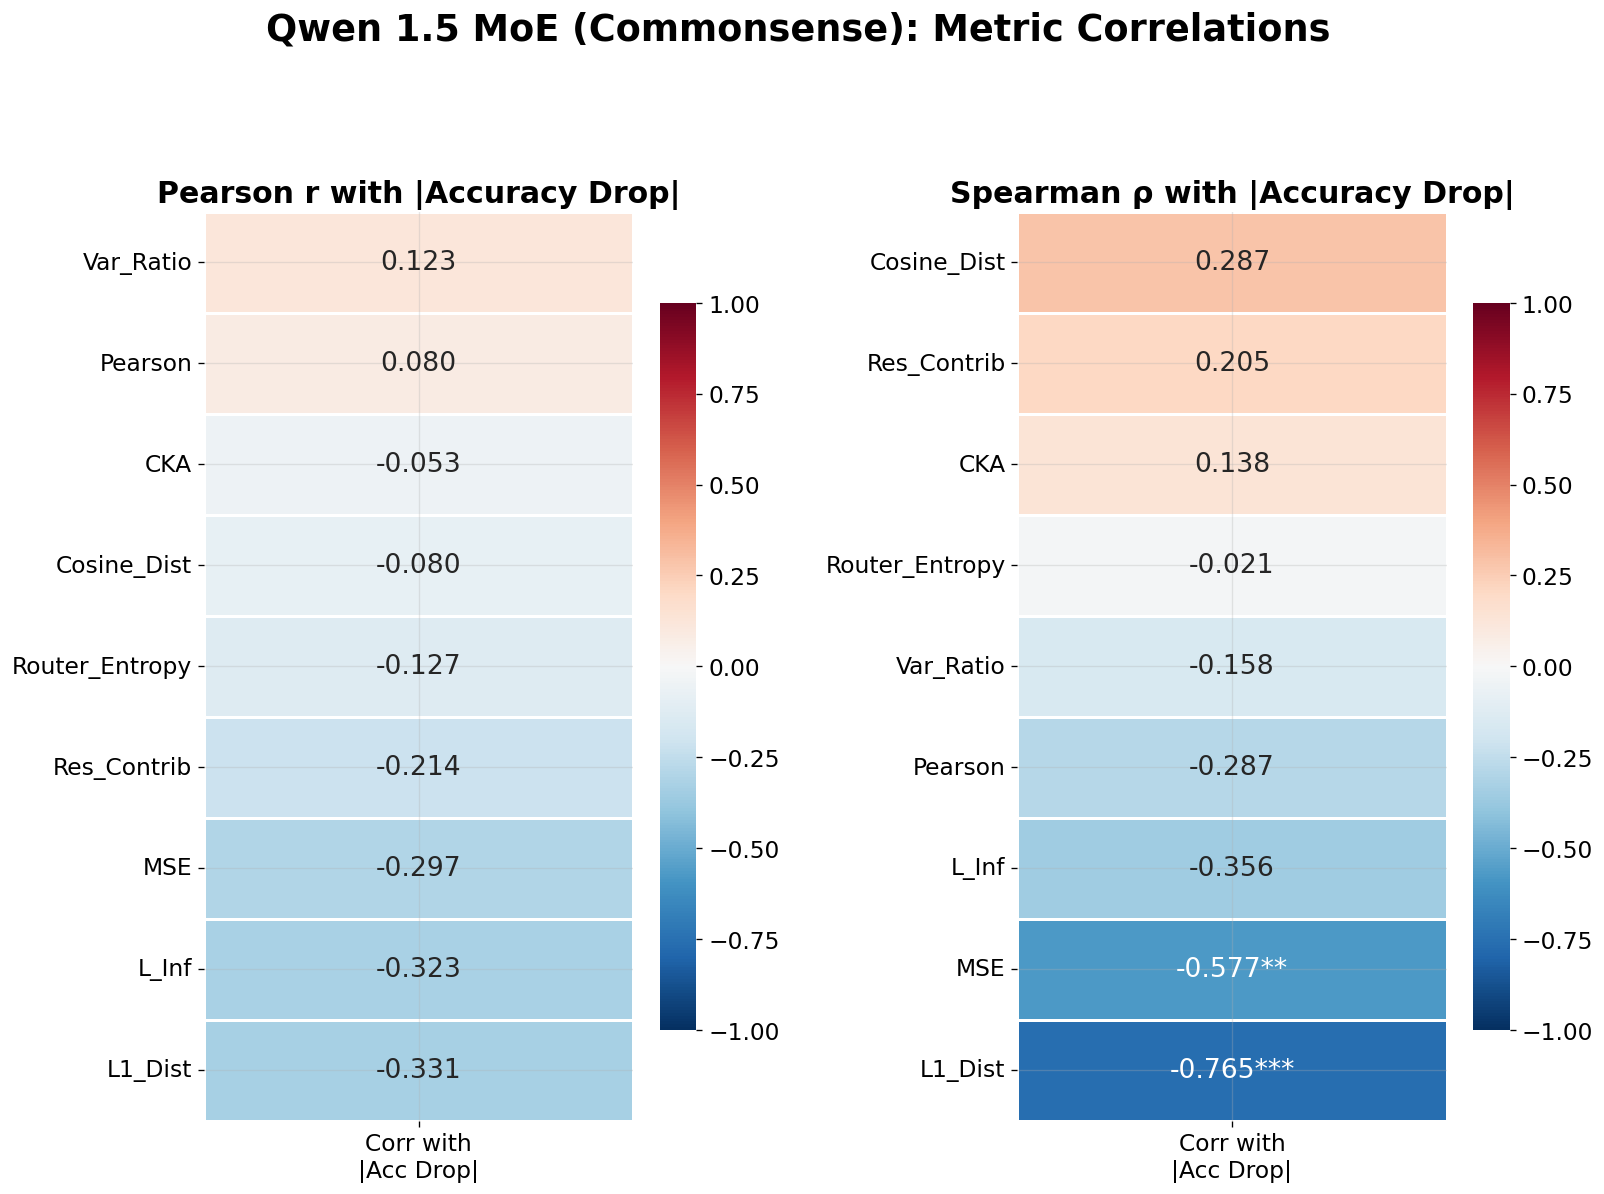

In [23]:
import seaborn as sns

# Basic metrics only (no proxy composites)
basic_metrics = ['MSE', 'Cosine_Dist', 'Res_Contrib', 'CKA',
                 'L1_Dist', 'L_Inf', 'Var_Ratio', 'Pearson', 'Router_Entropy']

corr_results = []
for mn in basic_metrics:
    pr, pp = stats.pearsonr(df_qwen['Abs_Drop'], df_qwen[mn])
    sr, sp = stats.spearmanr(df_qwen['Abs_Drop'], df_qwen[mn])
    corr_results.append({'Metric': mn,
                         'Pearson_r': round(pr, 4), 'Pearson_p': round(pp, 4),
                         'Spearman_r': round(sr, 4), 'Spearman_p': round(sp, 4)})
df_corr = pd.DataFrame(corr_results).sort_values('Pearson_r', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

for idx, (col, title) in enumerate([('Pearson_r', 'Pearson r'), ('Spearman_r', 'Spearman \u03c1')]):
    df_sorted = df_corr.sort_values(col, ascending=False)
    data = df_sorted[[col]].rename(columns={col: 'Corr with\n|Acc Drop|'})
    data.index = df_sorted['Metric']

    p_col = col.replace('_r', '_p')
    annot_vals = []
    for _, row in df_sorted.iterrows():
        v = row[col]
        p = row[p_col]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        annot_vals.append(f'{v:.3f}{sig}')
    annot_arr = np.array(annot_vals).reshape(-1, 1)

    sns.heatmap(data, annot=annot_arr, fmt='', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=axes[idx], linewidths=1.5, linecolor='white',
                cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f'{title} with |Accuracy Drop|', fontsize=18, fontweight='bold')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='y', labelsize=14)

plt.suptitle('Qwen 1.5 MoE (Commonsense): Metric Correlations',
             fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.0)
plt.show()

## Qwen 1.5 MoE (Commonsense)

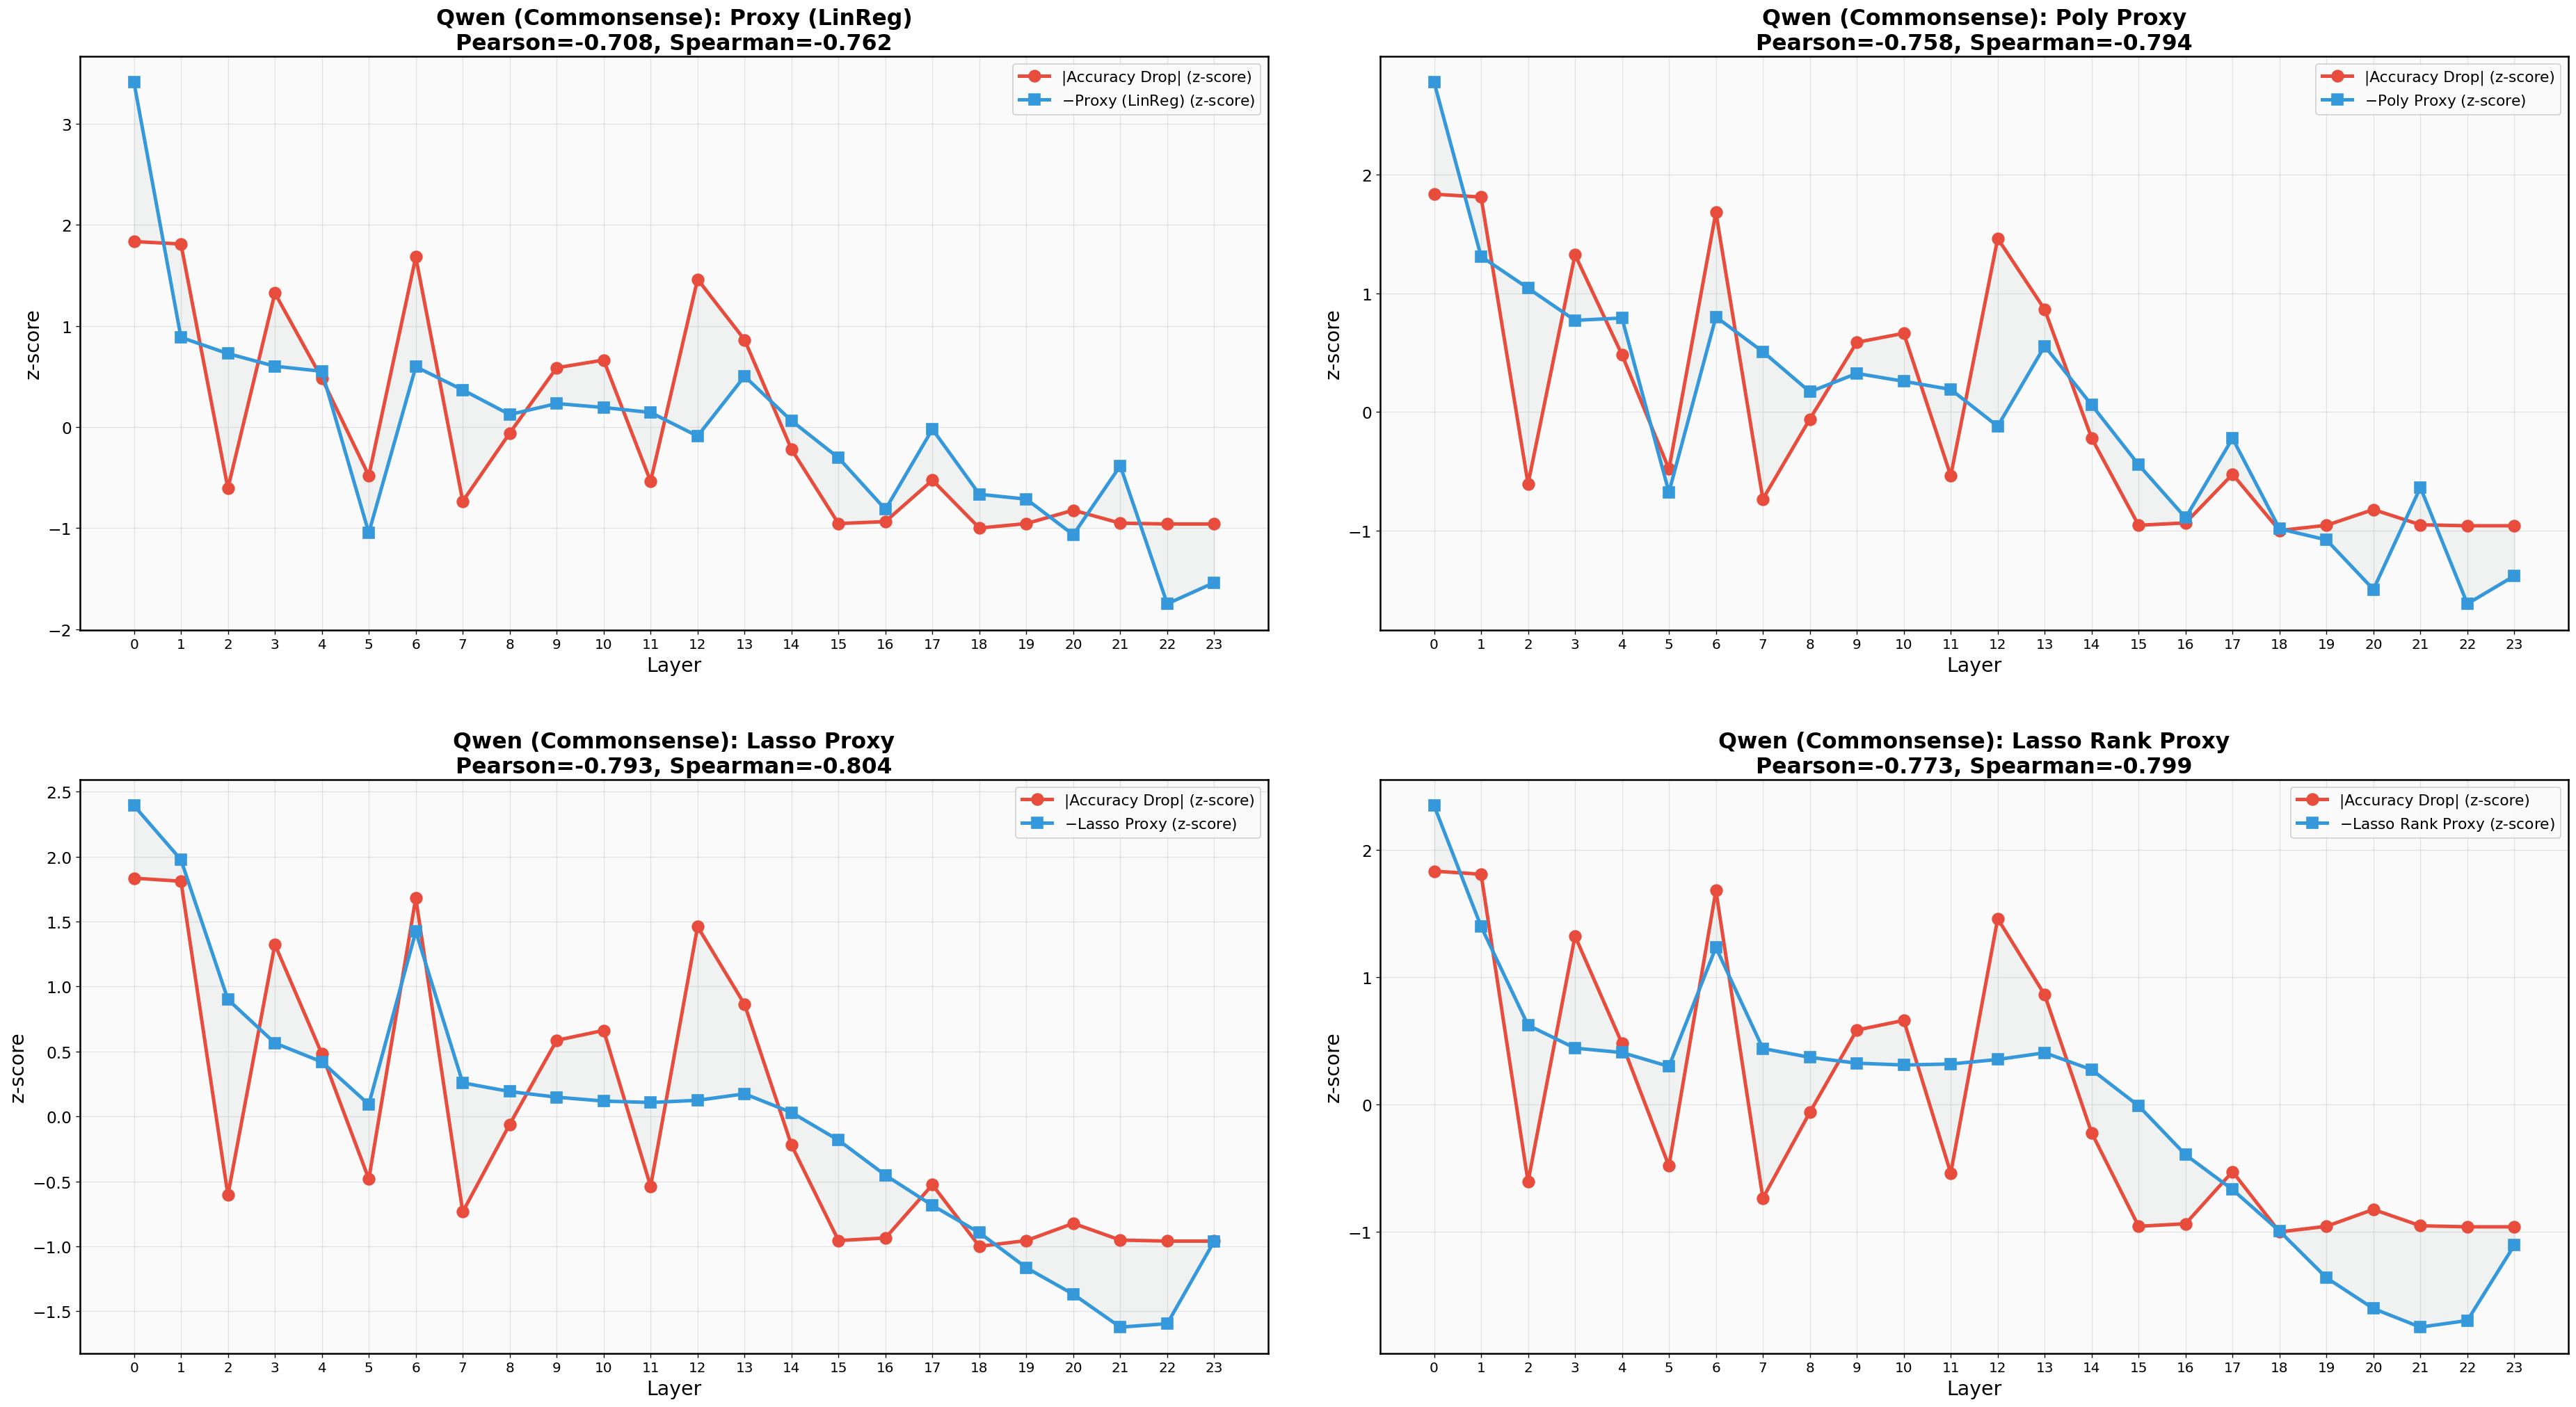

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(32, 18))
for idx, proxy_col in enumerate(proxy_names):
    plot_proxy_overlay(df_qwen, 'Qwen (Commonsense)', proxy_col, axes[idx // 2, idx % 2])
plt.tight_layout(pad=3.0)
plt.show()

## Phi-Tiny (Commonsense)

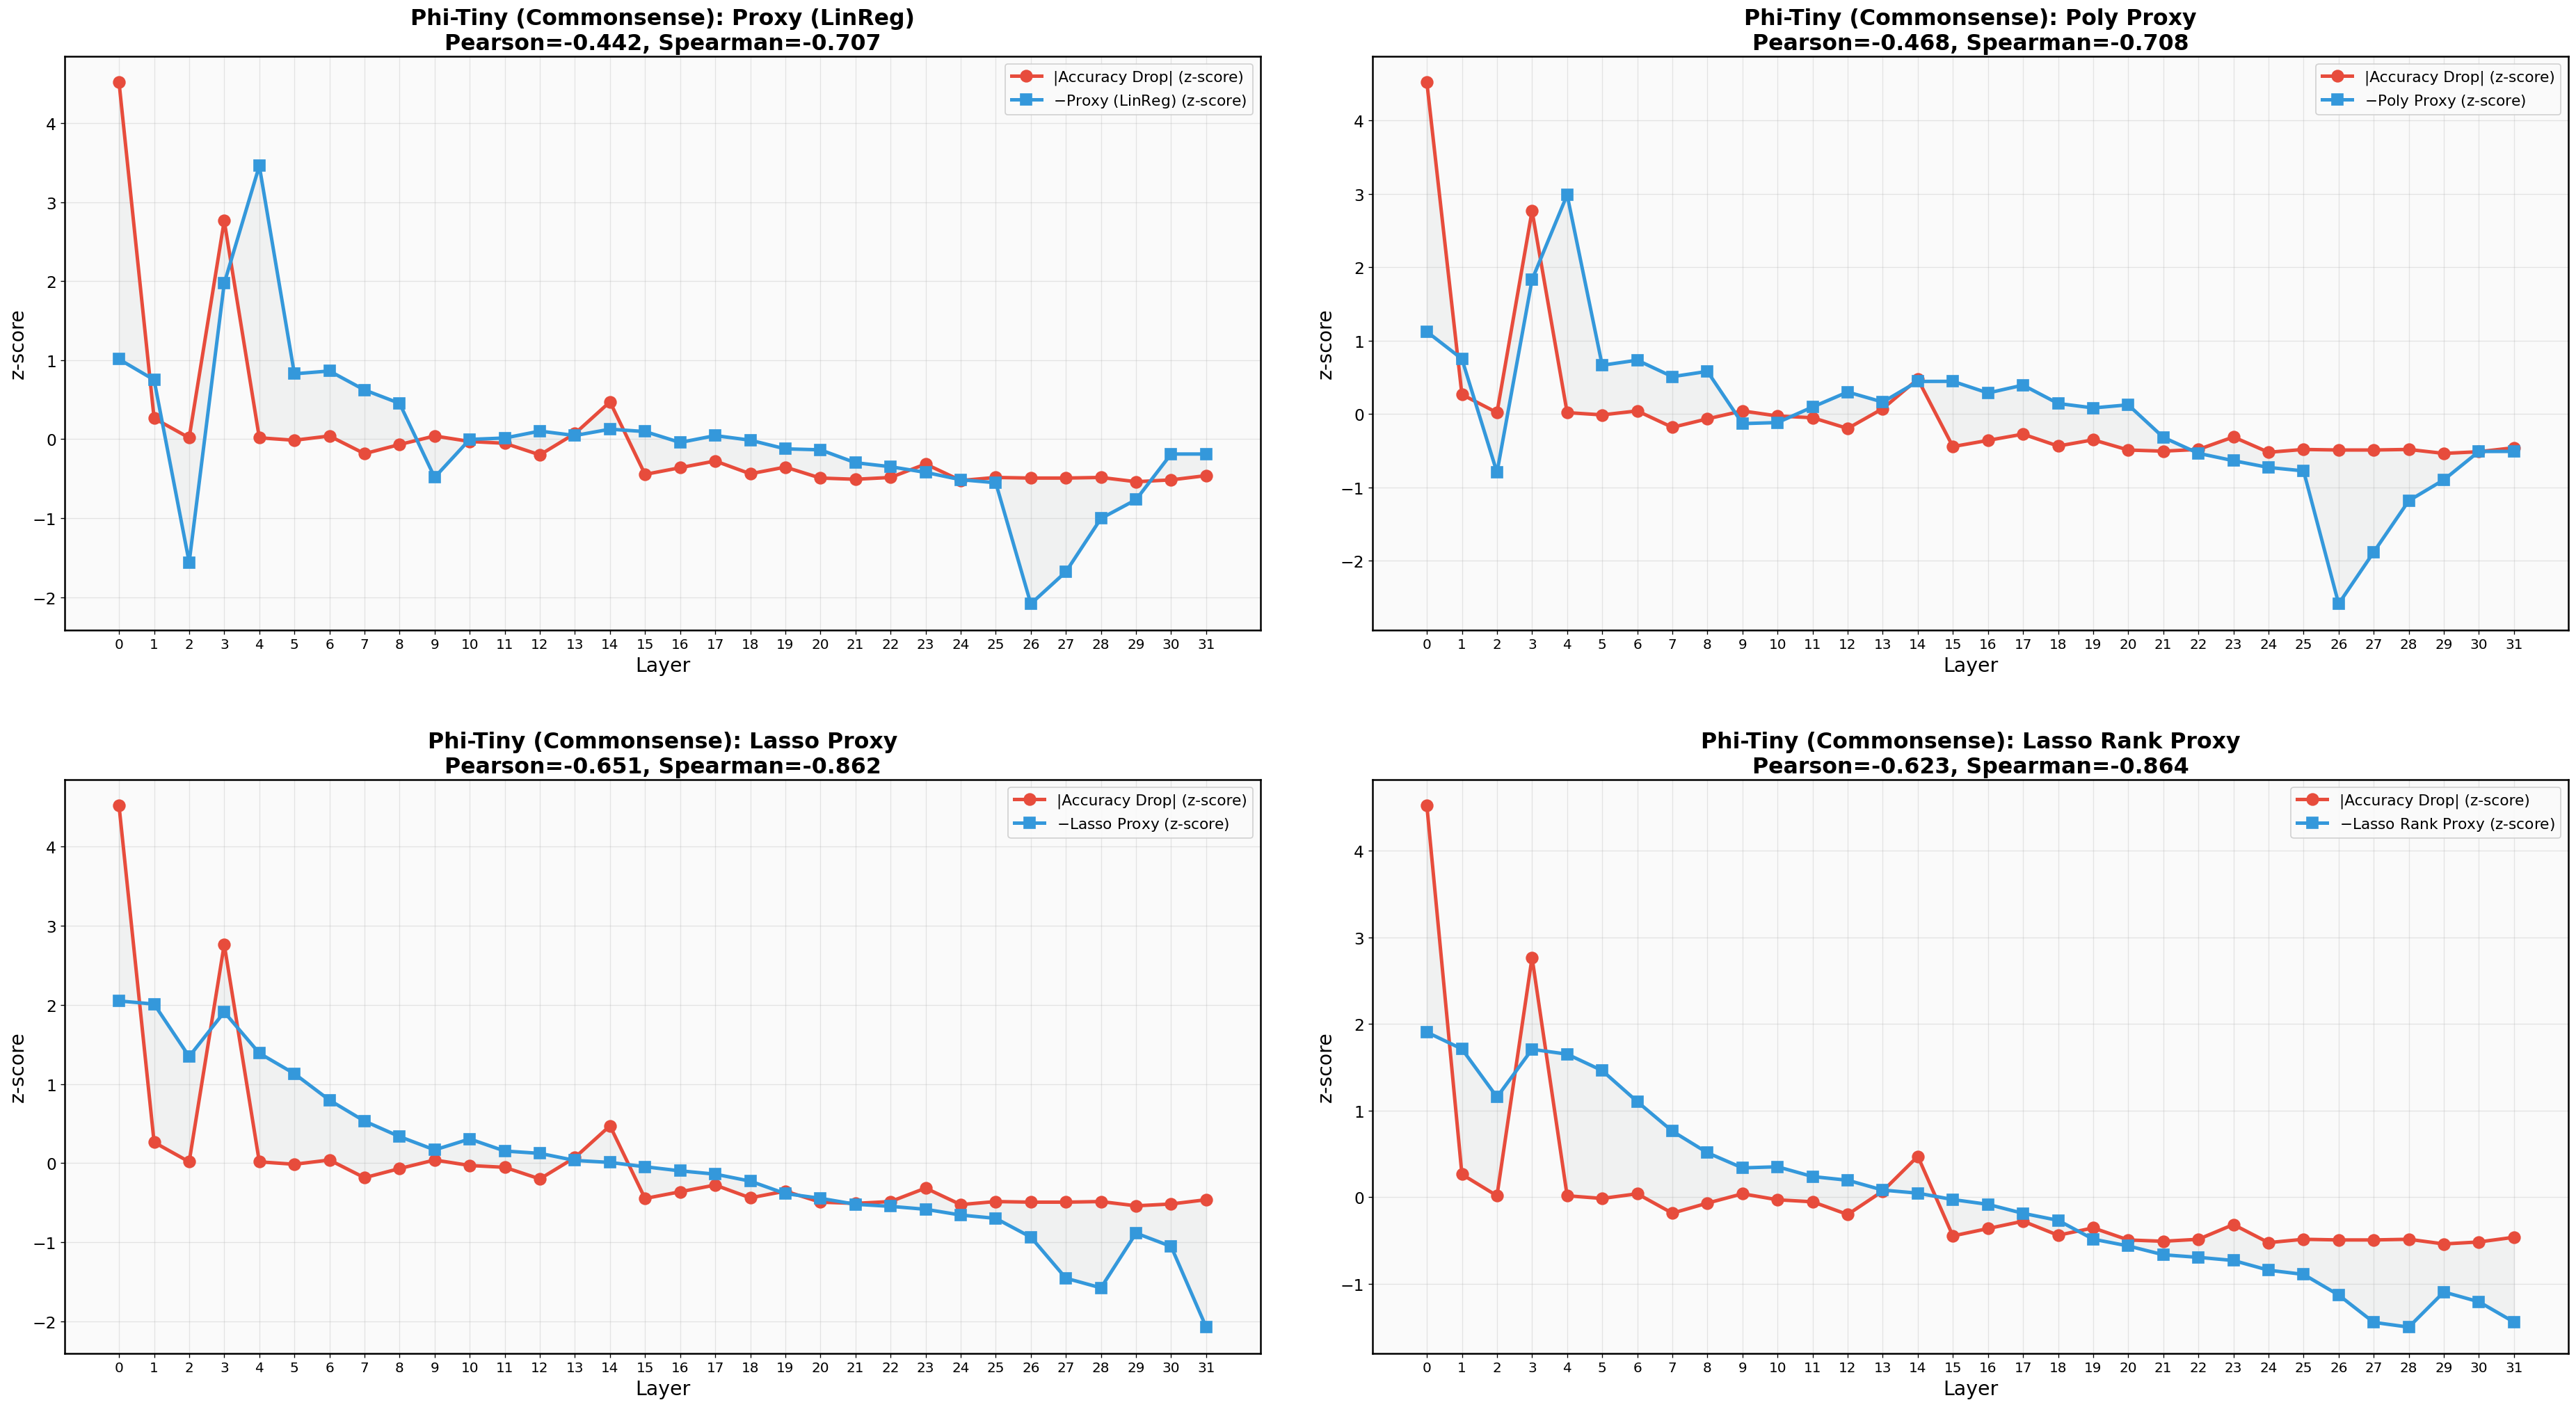

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(32, 18))
for idx, proxy_col in enumerate(proxy_names):
    plot_proxy_overlay(df_phi, 'Phi-Tiny (Commonsense)', proxy_col, axes[idx // 2, idx % 2])
plt.tight_layout(pad=3.0)
plt.show()

---
## SIQA

In [26]:
def load_siqa(acc_csv, metrics_dir, n_layers):
    acc_df = pd.read_csv(acc_csv)
    df = pd.DataFrame({'Layer': acc_df['Layer'].astype(int), 'Accuracy_Drop': acc_df['Ablation_Drop'].astype(float)})
    df['Abs_Drop'] = df['Accuracy_Drop'].abs()
    adj = {}
    for name, fn in matrix_files.items():
        dm = pd.read_csv(os.path.join(metrics_dir, fn), index_col=0)
        vals = [dm.iloc[i, i+1] if i < n_layers-1 else dm.iloc[i-1, i] for i in range(n_layers)]
        adj[name] = vals
    ent = pd.read_csv(os.path.join(metrics_dir, 'metric_09_Router_Entropy.csv'))
    adj['Router_Entropy'] = ent['Avg_Router_Entropy'].tolist()
    norm = {}
    for name, vals in adj.items():
        a = np.array(vals, dtype=float); s = a.std()
        norm[name] = (a - a.mean())/s if s > 0 else a - a.mean()
    proxy = np.zeros(n_layers)
    for name, c in proxy_coefficients.items():
        proxy += c * norm[name]
    adj['Proxy_Metric'] = proxy.tolist()
    feat_order = ['MSE','Cosine_Dist','Res_Contrib','CKA','L1_Dist','L_Inf','Var_Ratio','Pearson','Router_Entropy']
    X_raw = np.column_stack([np.array(adj[f], dtype=float) for f in feat_order])
    poly_t = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly_t.fit_transform(X_raw)
    pnames = list(poly_t.get_feature_names_out(feat_order))
    X_pn = (X_poly - X_poly.mean(axis=0)) / (X_poly.std(axis=0) + 1e-8)
    pp = np.zeros(n_layers)
    for fn, w in poly_weights.items():
        pp += w * X_pn[:, pnames.index(fn)]
    adj['Poly_Proxy'] = pp.tolist()
    lr = _compute_matrix_features(metrics_dir, lasso_feature_specs, n_layers)
    adj['Lasso_Proxy'] = _apply_weights(lr, lasso_weights, n_layers).tolist()
    lrr = _compute_matrix_features(metrics_dir, lasso_rank_specs, n_layers)
    adj['Lasso_Rank_Proxy'] = _apply_weights(lrr, lasso_rank_weights, n_layers).tolist()
    for name, vals in adj.items():
        df[name] = vals
    return df

df_qwen_siqa = load_siqa(os.path.join(BASE_DIR, "siqa", "Qwen metrics + layers", "accuracy data", "phi_tiny_siqa_ablations.csv"),
                          os.path.join(BASE_DIR, "siqa", "Qwen metrics + layers", "metric data", "metrics"), 24)
df_phi_siqa = load_siqa(os.path.join(BASE_DIR, "siqa", "phi-tiny metrics + layers", "accuracy data", "phi_tiny_siqa_ablations.csv"),
                         os.path.join(BASE_DIR, "siqa", "phi-tiny metrics + layers", "metric data", "metrics"), 32)
print(f'SIQA: Qwen {len(df_qwen_siqa)} layers, Phi {len(df_phi_siqa)} layers')

SIQA: Qwen 24 layers, Phi 32 layers


## Qwen 1.5 MoE (SIQA)

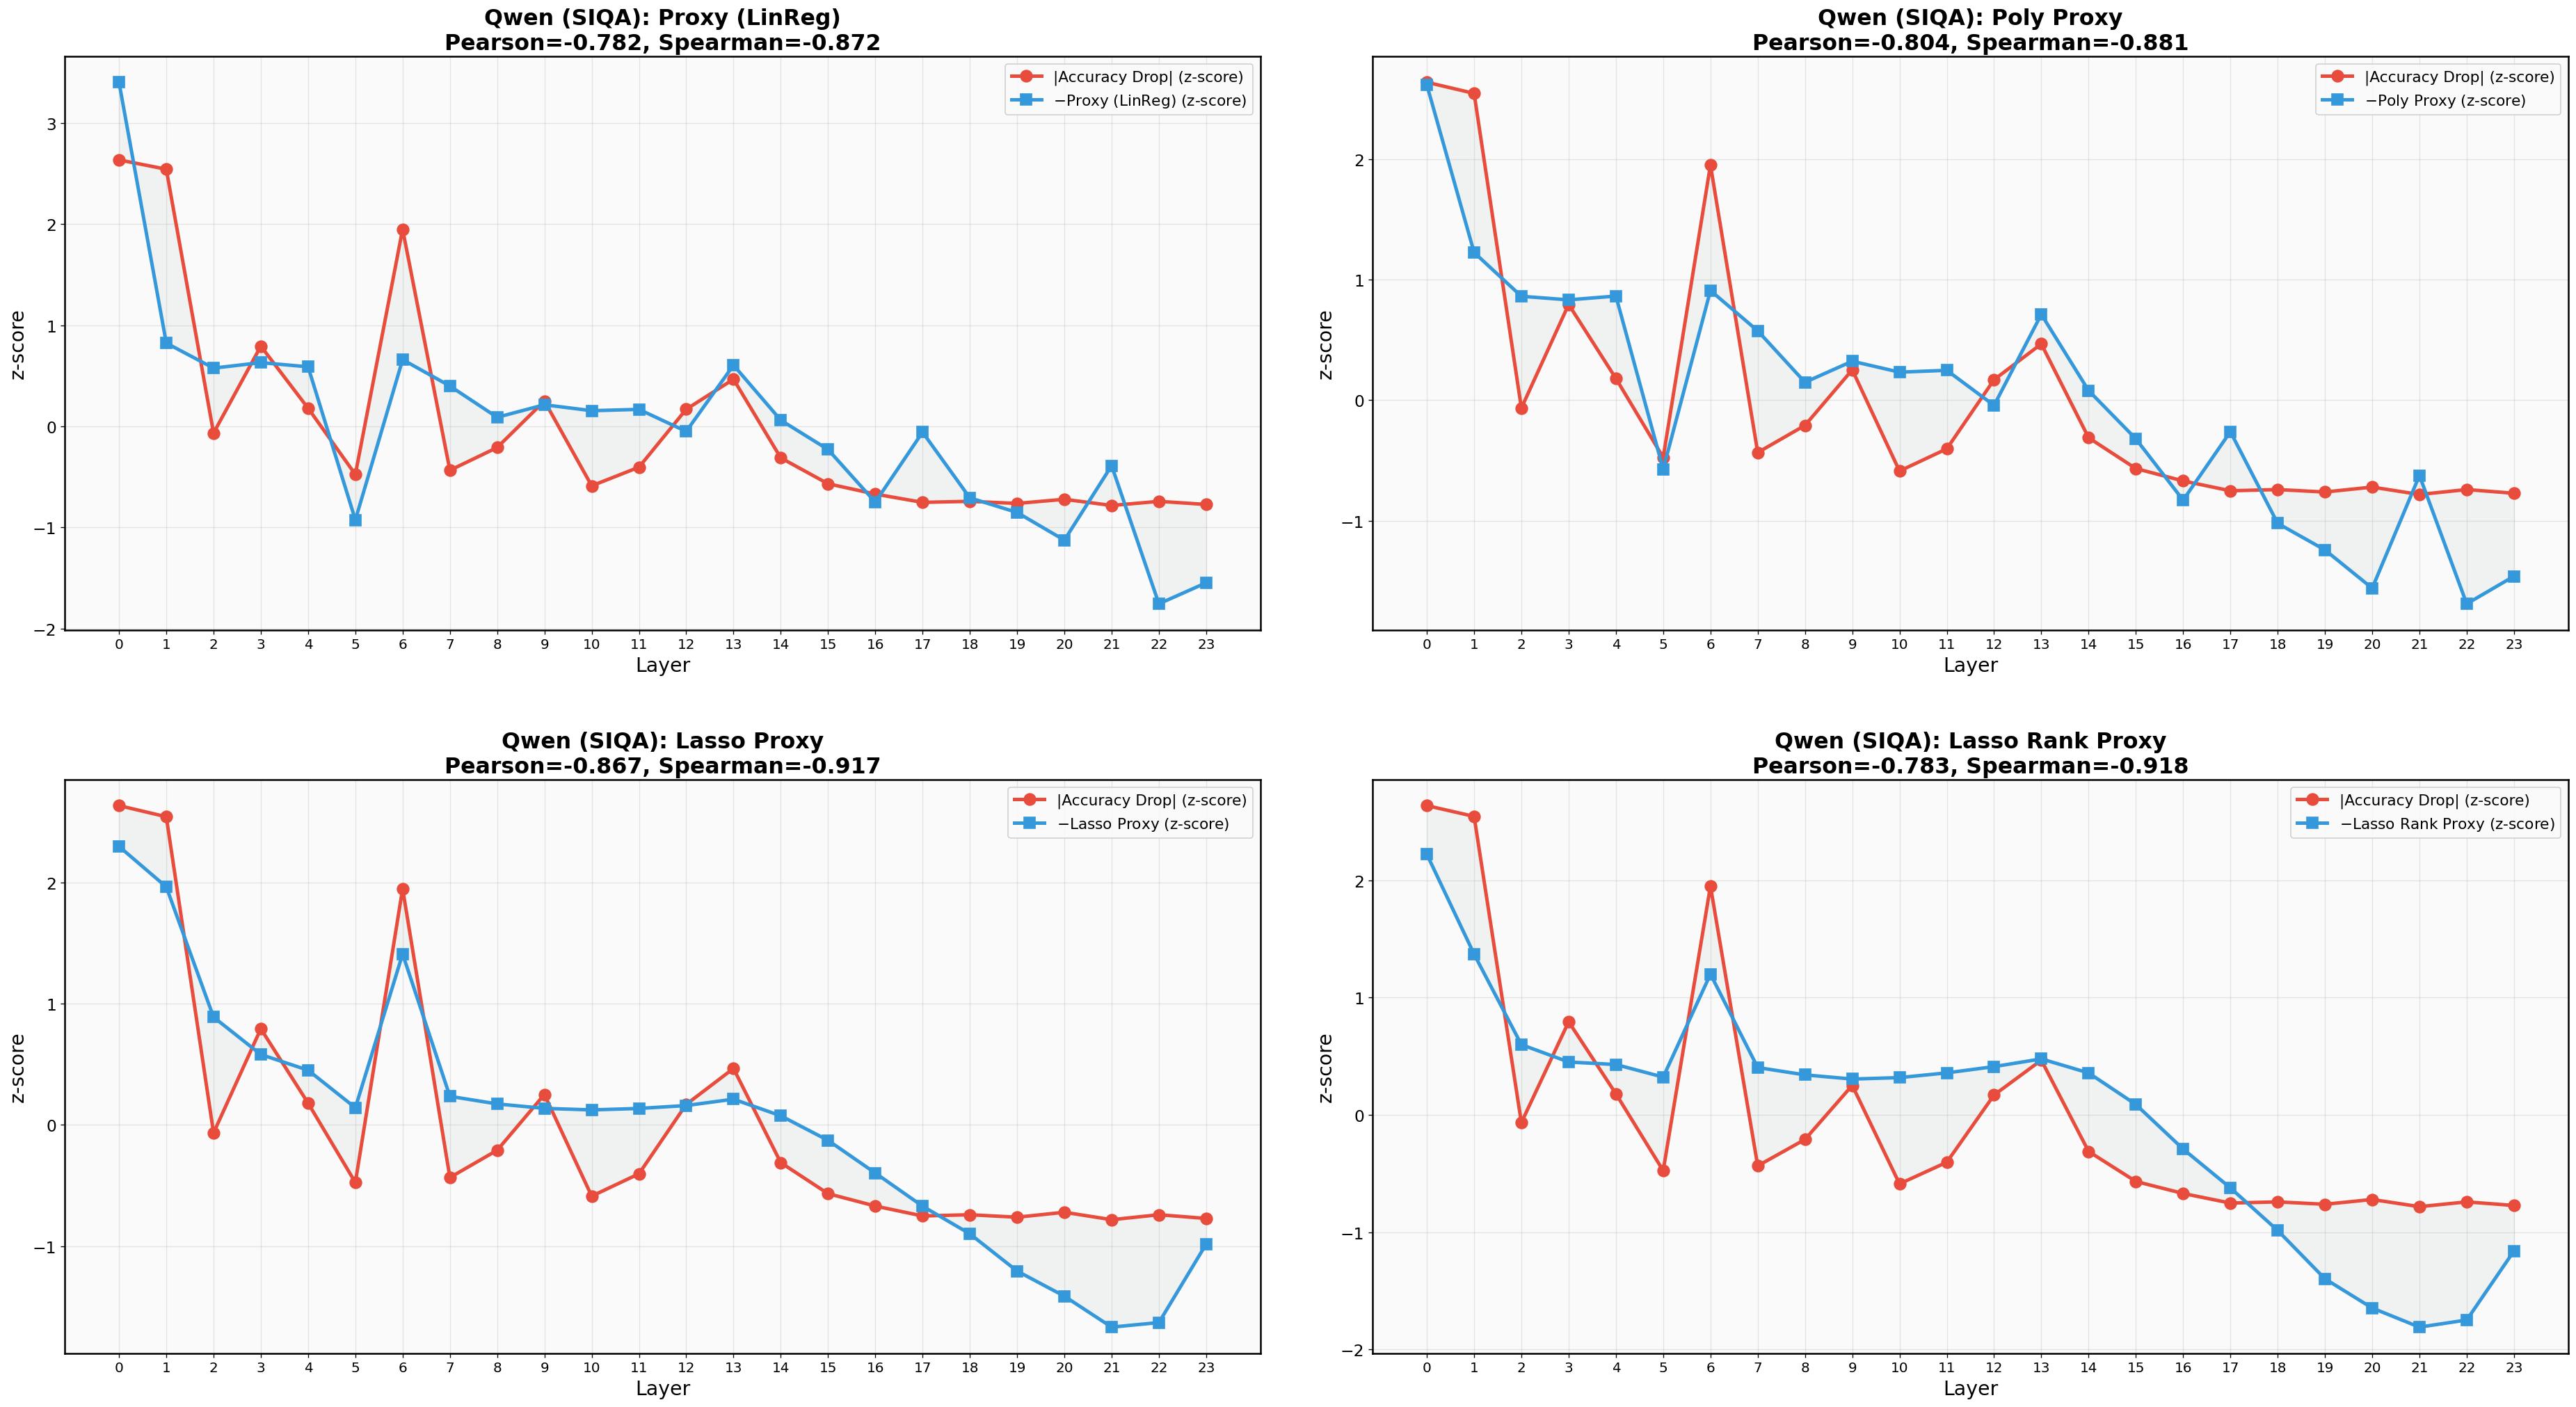

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(32, 18))
for idx, proxy_col in enumerate(proxy_names):
    plot_proxy_overlay(df_qwen_siqa, 'Qwen (SIQA)', proxy_col, axes[idx // 2, idx % 2])
plt.tight_layout(pad=3.0)
plt.show()

## Phi-Tiny (SIQA)

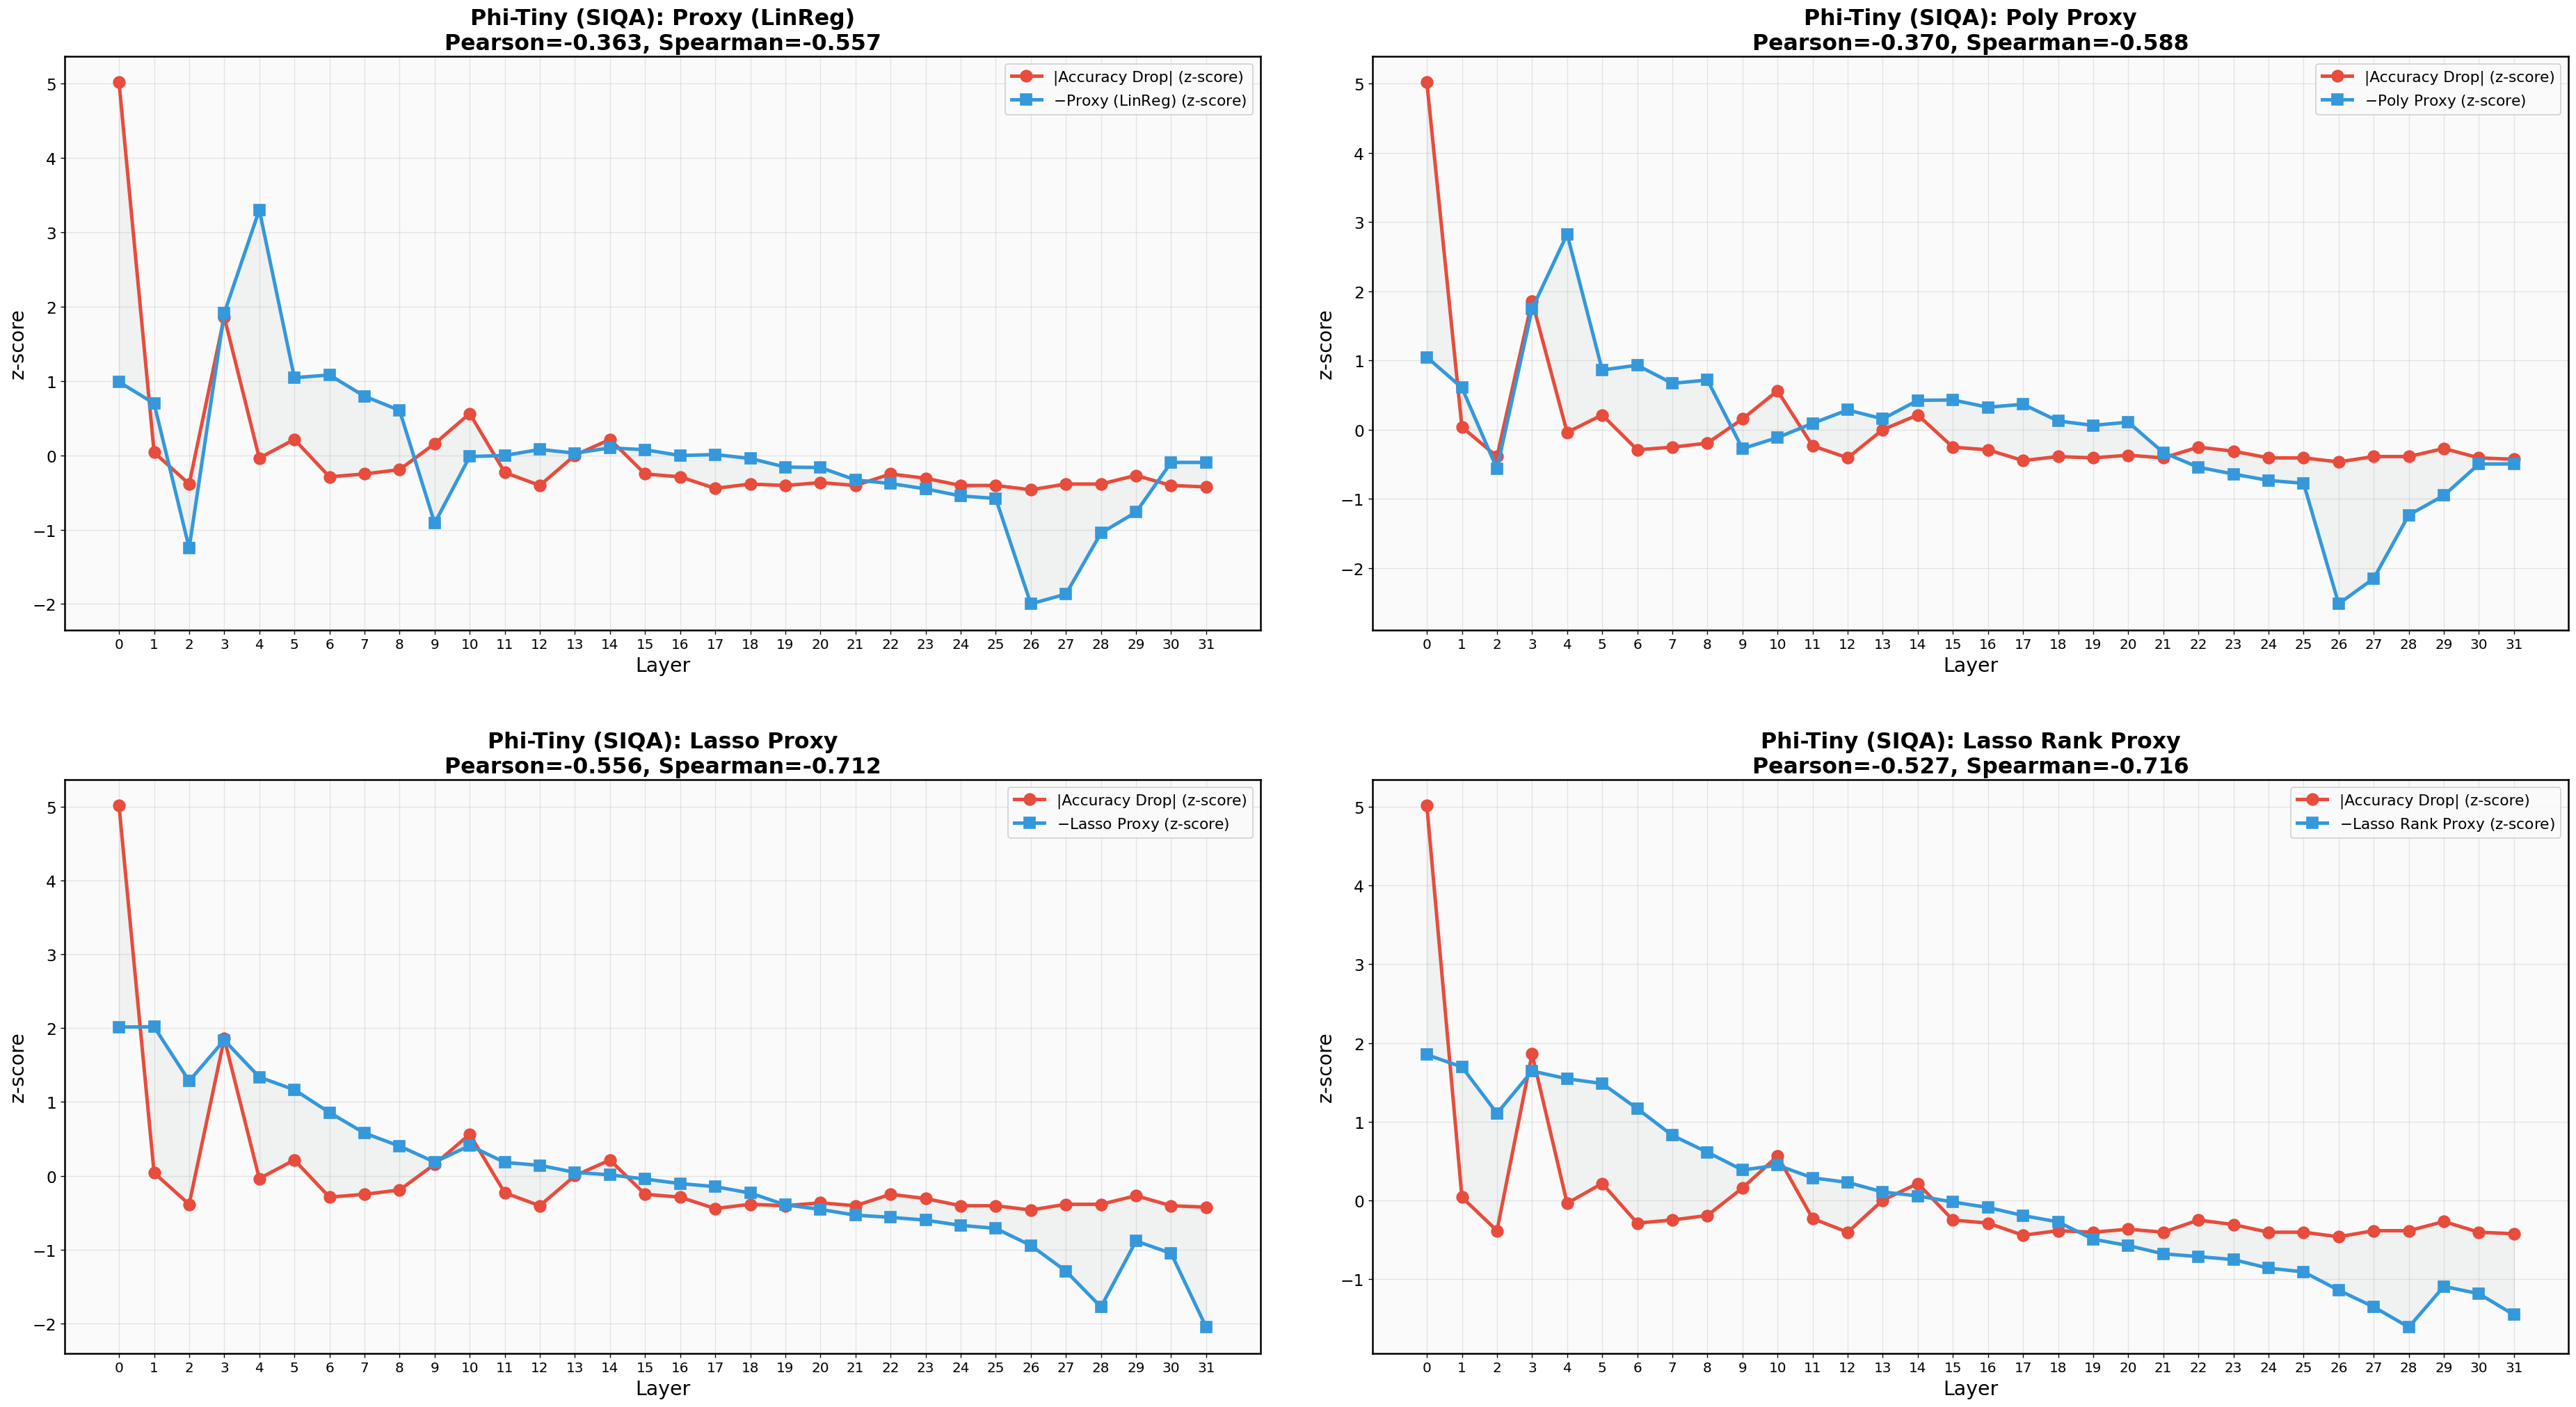

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(32, 18))
for idx, proxy_col in enumerate(proxy_names):
    plot_proxy_overlay(df_phi_siqa, 'Phi-Tiny (SIQA)', proxy_col, axes[idx // 2, idx % 2])
plt.tight_layout(pad=3.0)
plt.show()

## Сводная таблица корреляций

## Ранговый анализ: Top-5 наименее важных слоёв

In [29]:
def rank_comparison(df_m, model_name, proxy_col='Proxy_Metric'):
    """Compute rank comparison between Accuracy Drop and Proxy metric."""
    df_r = df_m[['Layer', 'Abs_Drop', proxy_col]].copy()
    # method='first' ensures unique integer ranks (no ties)
    df_r['Rank_Drop'] = df_r['Abs_Drop'].rank(ascending=True, method='first').astype(int)
    df_r['Rank_Proxy'] = df_r[proxy_col].rank(ascending=False, method='first').astype(int)
    df_r['Rank_Diff'] = (df_r['Rank_Drop'] - df_r['Rank_Proxy']).abs()
    df_r = df_r.sort_values('Rank_Drop')
    return df_r

# Compute ranks for all proxy types on both models (commonsense)
proxy_names = ['Proxy_Metric', 'Poly_Proxy', 'Lasso_Proxy', 'Lasso_Rank_Proxy']

ranks = {}
for proxy_col in proxy_names:
    ranks[('Qwen', proxy_col)] = rank_comparison(df_qwen, 'Qwen', proxy_col)
    ranks[('Phi', proxy_col)] = rank_comparison(df_phi, 'Phi-Tiny', proxy_col)

print('Ranks computed')

Ranks computed


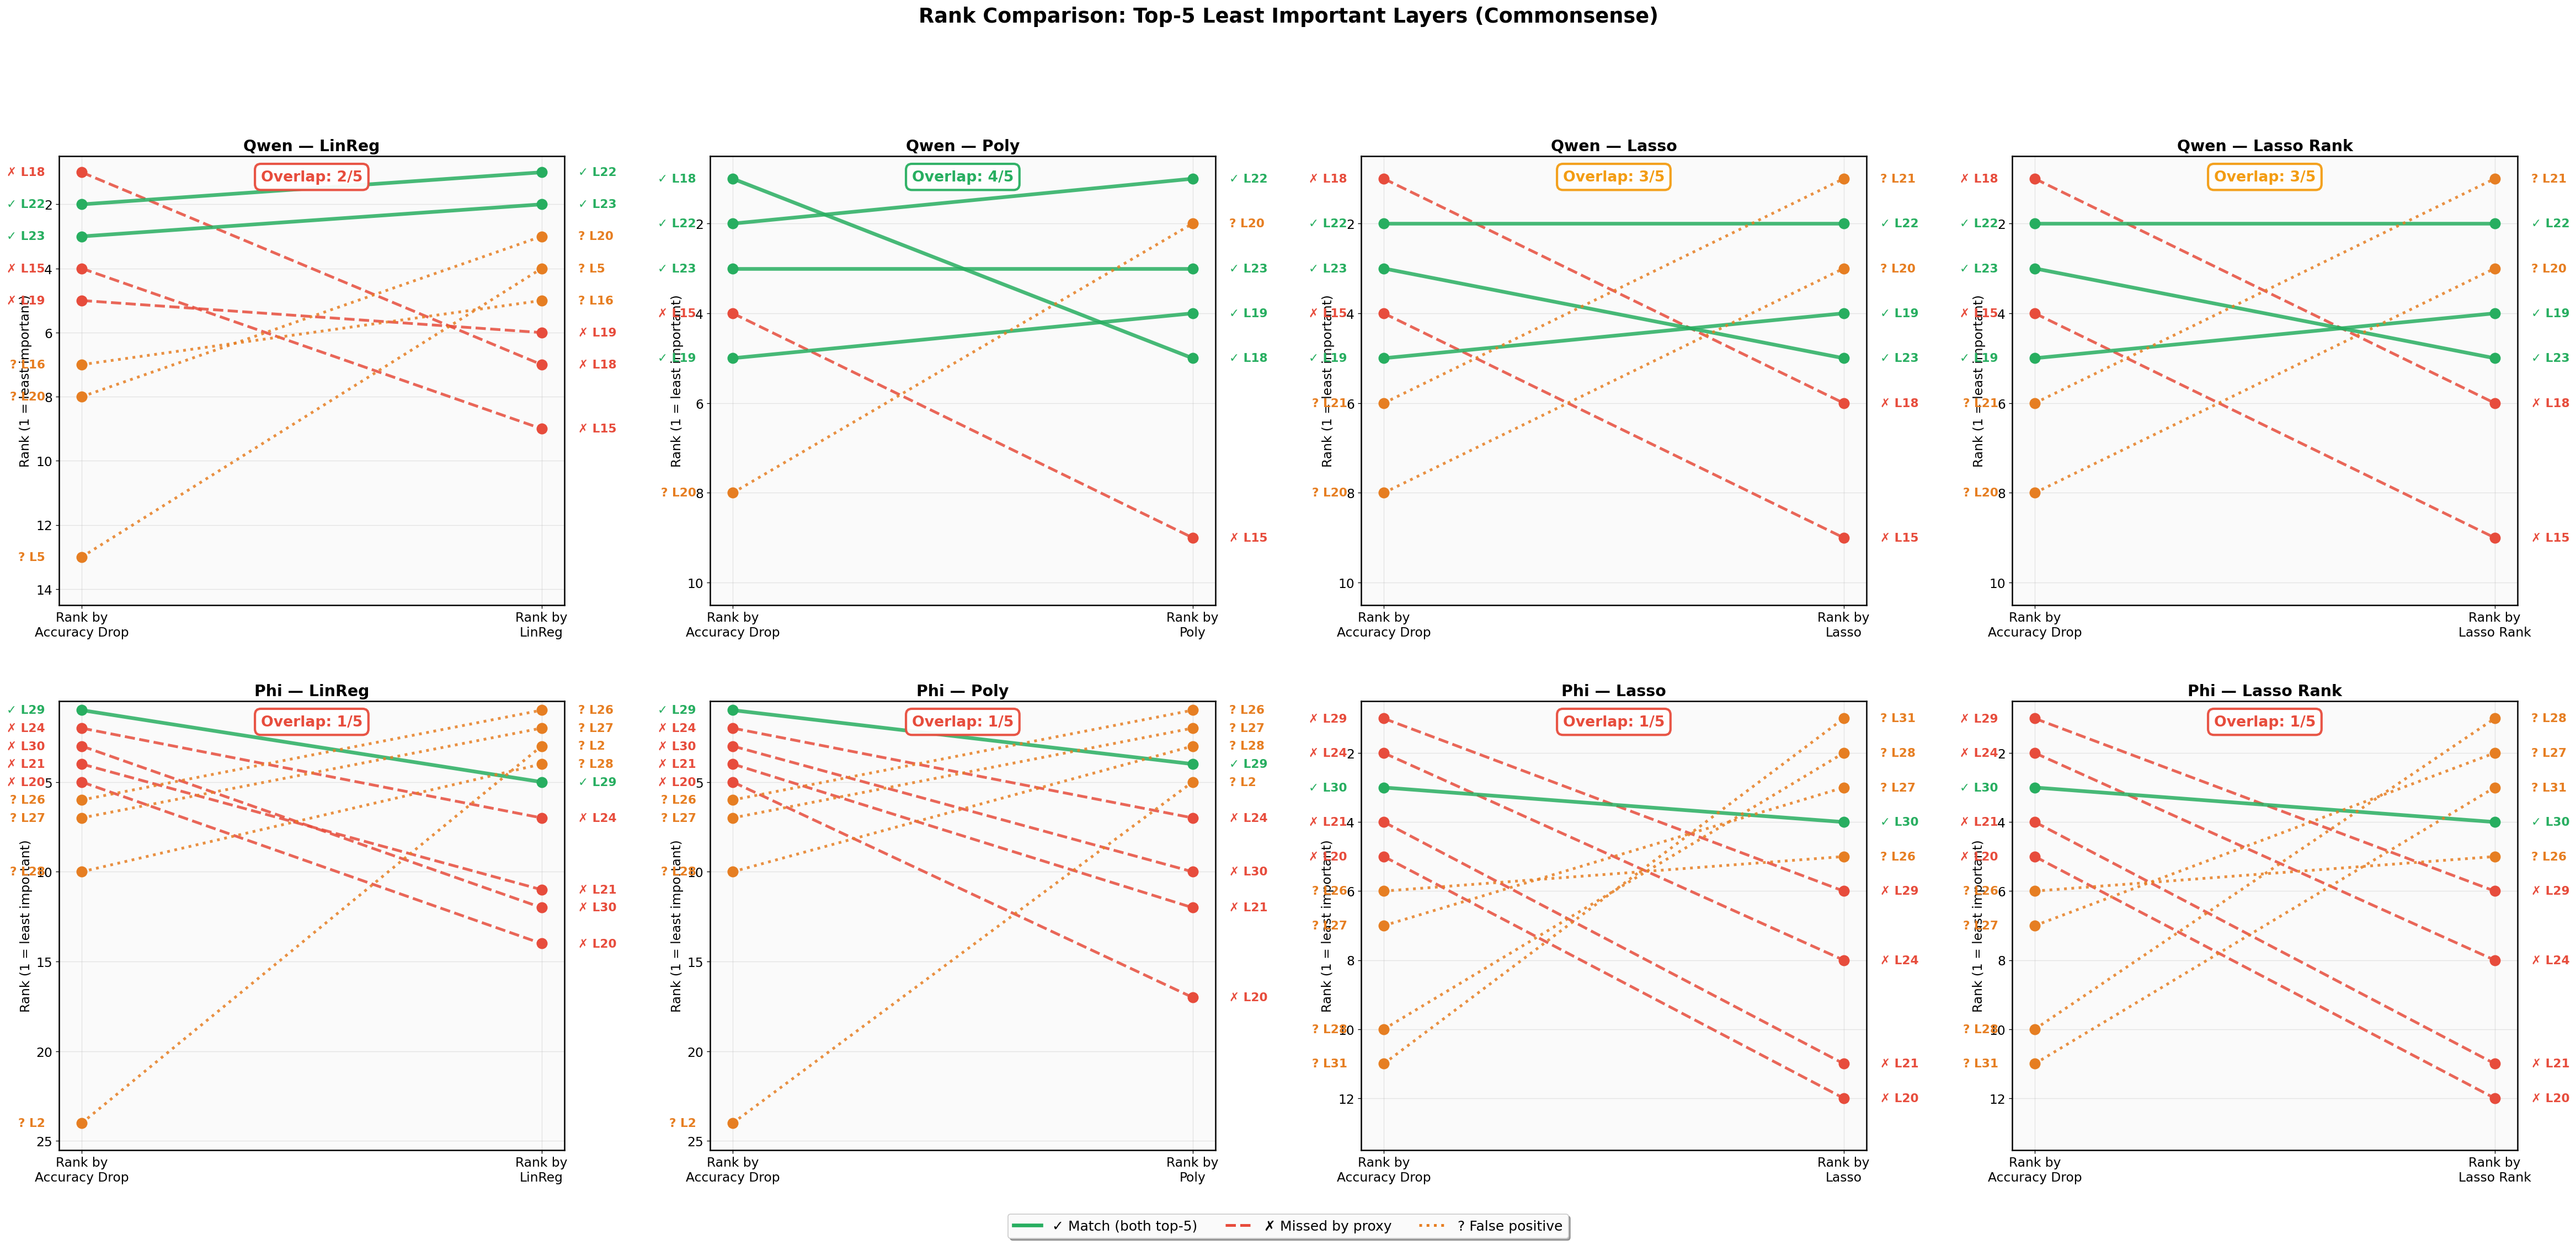

In [30]:
# Bump chart: TOP-5 LEAST important layers
# Green solid  = correctly identified (in both top-5)
# Red dashed   = missed by proxy (in top-5 drop only)
# Orange dotted = false positive (in top-5 proxy only)

proxy_short = {
    'Proxy_Metric': 'LinReg', 'Poly_Proxy': 'Poly',
    'Lasso_Proxy': 'Lasso', 'Lasso_Rank_Proxy': 'Lasso Rank',
}

fig, axes = plt.subplots(2, 4, figsize=(40, 18))

configs = [
    ('Qwen \u2014 LinReg',       'Qwen', 'Proxy_Metric'),
    ('Qwen \u2014 Poly',         'Qwen', 'Poly_Proxy'),
    ('Qwen \u2014 Lasso',        'Qwen', 'Lasso_Proxy'),
    ('Qwen \u2014 Lasso Rank',   'Qwen', 'Lasso_Rank_Proxy'),
    ('Phi \u2014 LinReg',        'Phi',  'Proxy_Metric'),
    ('Phi \u2014 Poly',          'Phi',  'Poly_Proxy'),
    ('Phi \u2014 Lasso',         'Phi',  'Lasso_Proxy'),
    ('Phi \u2014 Lasso Rank',    'Phi',  'Lasso_Rank_Proxy'),
]

TOP_K = 5

for flat_idx, (title, model_key, pcol) in enumerate(configs):
    row, col = flat_idx // 4, flat_idx % 4
    ax = axes[row, col]

    df_r = ranks[(model_key, pcol)]
    n = len(df_r)

    top_drop = set(df_r.nsmallest(TOP_K, 'Rank_Drop')['Layer'].values)
    top_proxy = set(df_r.nsmallest(TOP_K, 'Rank_Proxy')['Layer'].values)
    matched = top_drop & top_proxy
    missed = top_drop - top_proxy      # proxy didn't catch these
    false_pos = top_proxy - top_drop   # proxy wrongly flagged these
    show_layers = top_drop | top_proxy

    df_top = df_r[df_r['Layer'].isin(show_layers)]

    for _, r in df_top.iterrows():
        layer = r['Layer']
        if layer in matched:
            color, ls, lw, marker_ec = '#27ae60', '-', 4.0, '#27ae60'
            label_prefix = '\u2713 '
        elif layer in missed:
            color, ls, lw, marker_ec = '#e74c3c', '--', 3.0, '#e74c3c'
            label_prefix = '\u2717 '
        else:  # false_pos
            color, ls, lw, marker_ec = '#e67e22', ':', 3.0, '#e67e22'
            label_prefix = '? '

        ax.plot([0, 1], [r['Rank_Drop'], r['Rank_Proxy']], linestyle=ls,
                color=color, alpha=0.85, markersize=0, linewidth=lw)
        # Left marker
        ax.plot(0, r['Rank_Drop'], 'o', color=color, markersize=11, zorder=6)
        ax.text(-0.08, r['Rank_Drop'], f"{label_prefix}L{int(layer)}",
                ha='right', va='center', fontsize=13, fontweight='bold',
                color=color)
        # Right marker
        ax.plot(1, r['Rank_Proxy'], 'o', color=color, markersize=11, zorder=6)
        ax.text(1.08, r['Rank_Proxy'], f"{label_prefix}L{int(layer)}",
                ha='left', va='center', fontsize=13, fontweight='bold',
                color=color)

    all_ranks = list(df_top['Rank_Drop']) + list(df_top['Rank_Proxy'])
    margin = 1
    ymin = max(1, min(all_ranks) - margin)
    ymax = min(n, max(all_ranks) + margin)
    ax.set_ylim(ymax + 0.5, ymin - 0.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rank by\nAccuracy Drop', f'Rank by\n{proxy_short[pcol]}'], fontsize=14)
    ax.set_ylabel('Rank (1 = least important)', fontsize=14)
    ax.set_title(title, fontsize=17, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Overlap badge
    overlap = len(matched)
    ov_color = '#27ae60' if overlap >= 4 else '#f39c12' if overlap >= 3 else '#e74c3c'
    ax.text(0.5, 0.97, f'Overlap: {overlap}/{TOP_K}',
            transform=ax.transAxes, ha='center', va='top', fontsize=16, fontweight='bold',
            color=ov_color,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=ov_color, linewidth=2.5, alpha=0.95))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#27ae60', linewidth=4, linestyle='-',  label='\u2713 Match (both top-5)'),
    Line2D([0], [0], color='#e74c3c', linewidth=3, linestyle='--', label='\u2717 Missed by proxy'),
    Line2D([0], [0], color='#e67e22', linewidth=3, linestyle=':',  label='? False positive'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=15,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Rank Comparison: Top-{TOP_K} Least Important Layers (Commonsense)',
             fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)
plt.subplots_adjust(bottom=0.06)
plt.show()


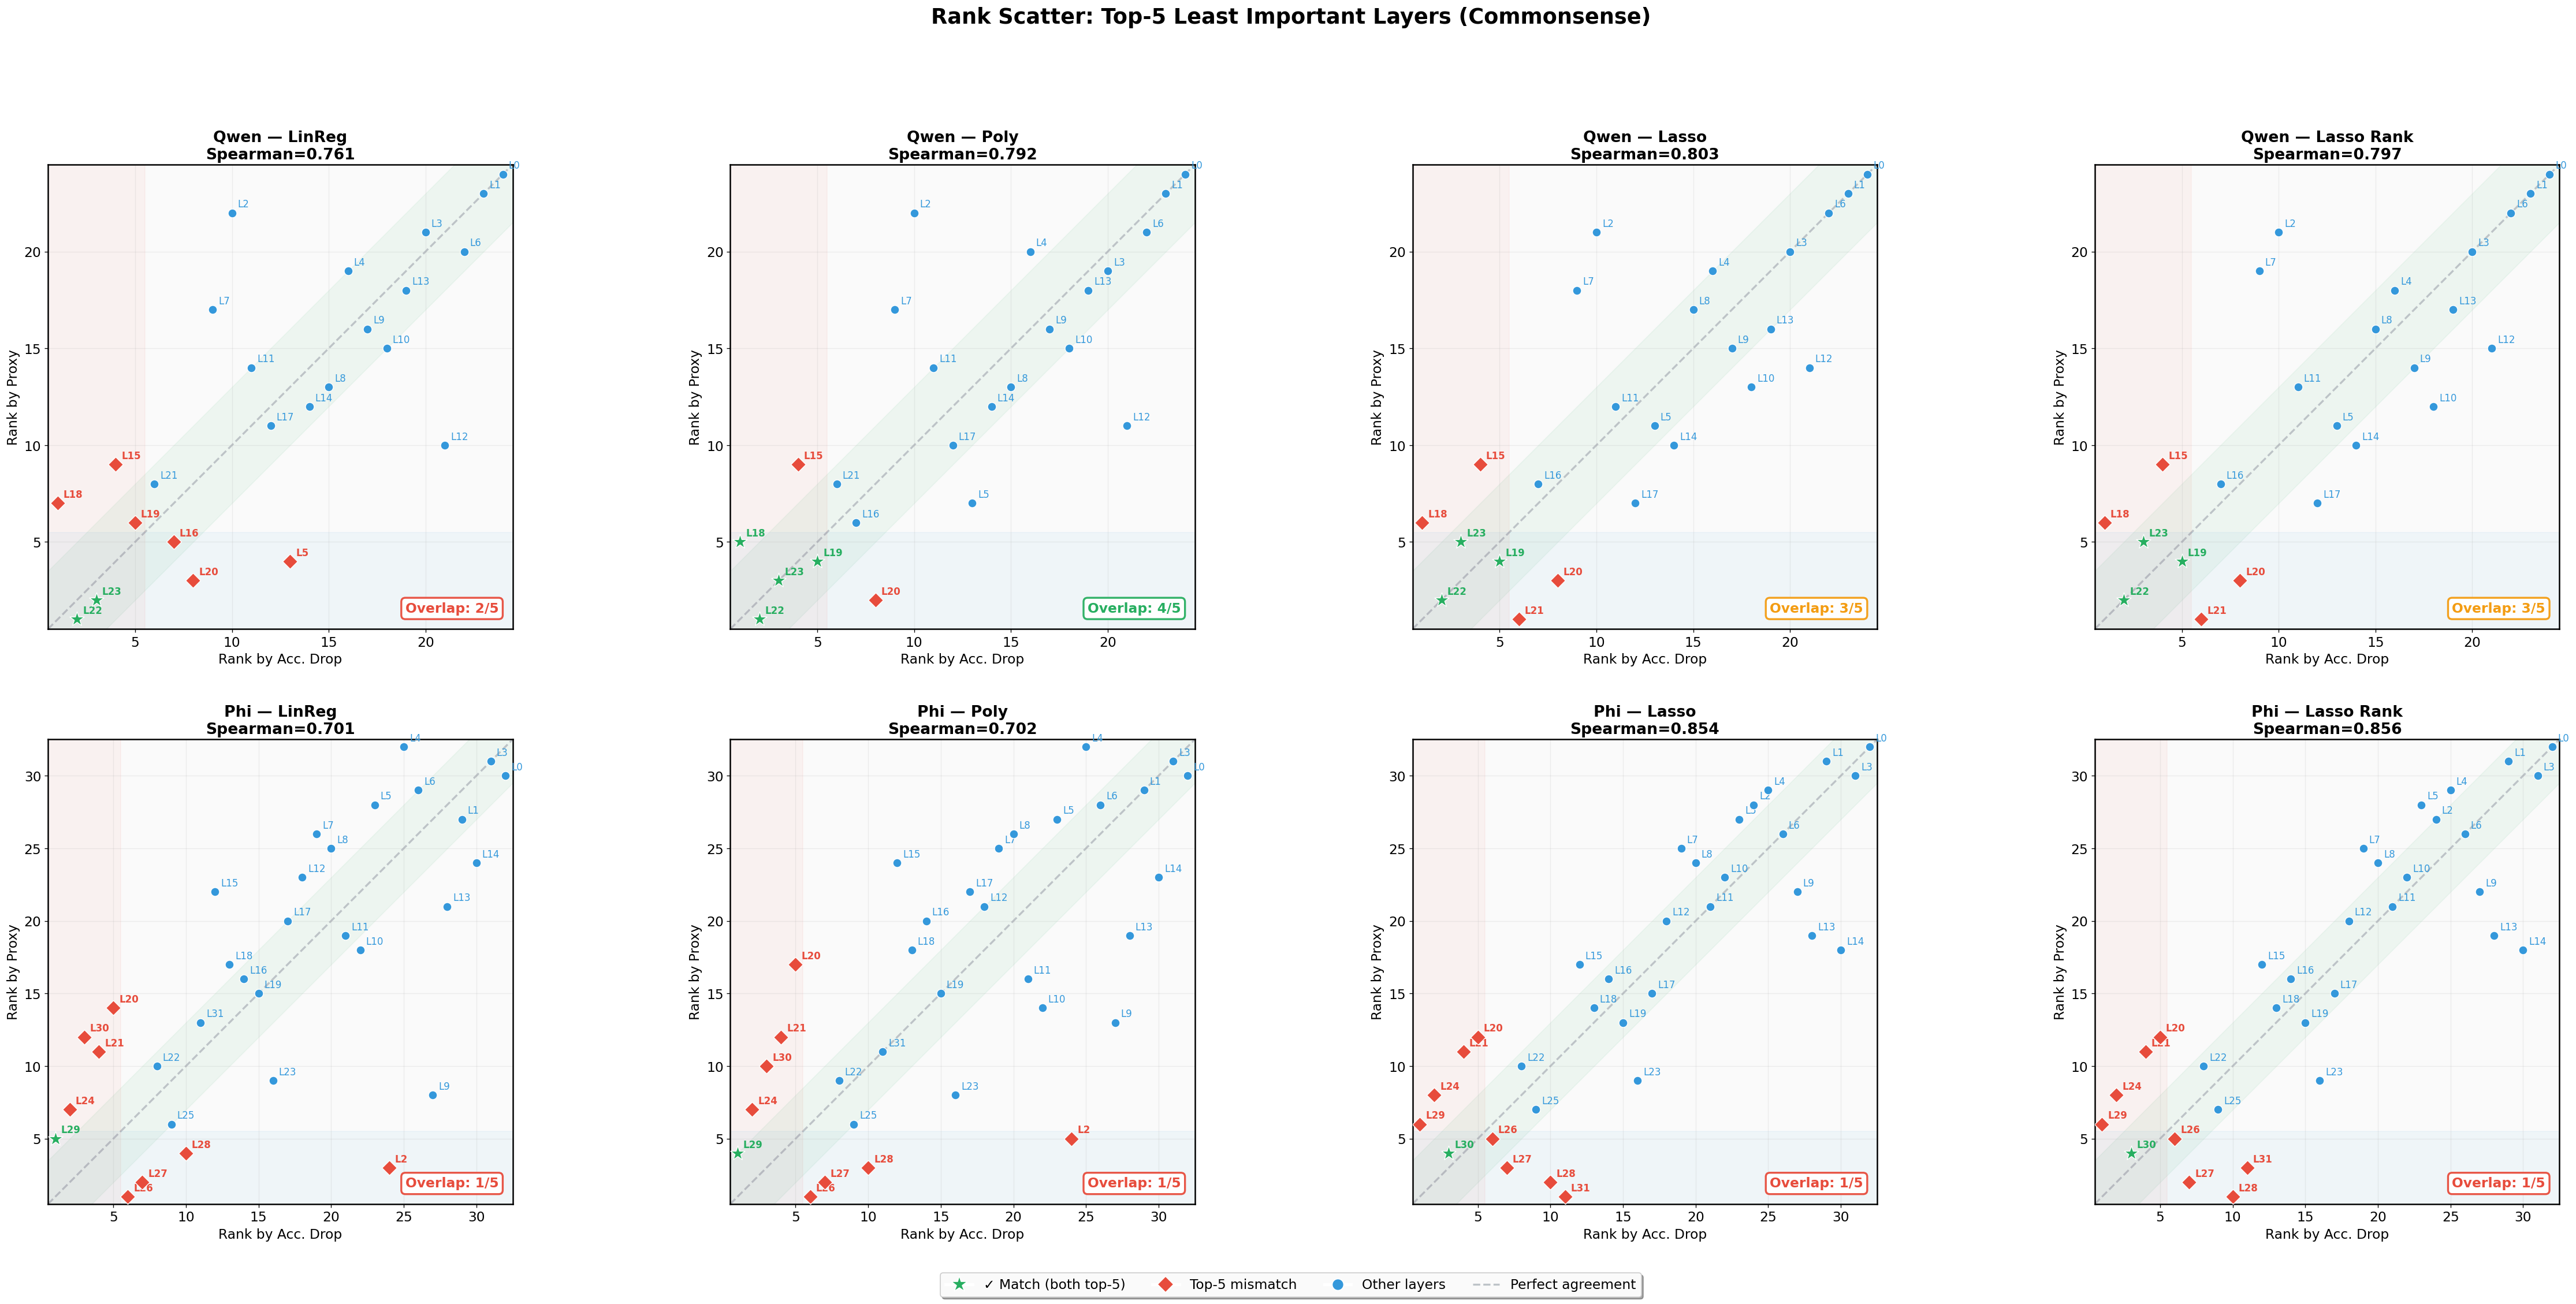

In [31]:
# Rank scatter plot: all proxies, Commonsense

fig, axes = plt.subplots(2, 4, figsize=(40, 18))

configs = [
    ('Qwen \u2014 LinReg',       'Qwen', 'Proxy_Metric'),
    ('Qwen \u2014 Poly',         'Qwen', 'Poly_Proxy'),
    ('Qwen \u2014 Lasso',        'Qwen', 'Lasso_Proxy'),
    ('Qwen \u2014 Lasso Rank',   'Qwen', 'Lasso_Rank_Proxy'),
    ('Phi \u2014 LinReg',        'Phi',  'Proxy_Metric'),
    ('Phi \u2014 Poly',          'Phi',  'Poly_Proxy'),
    ('Phi \u2014 Lasso',         'Phi',  'Lasso_Proxy'),
    ('Phi \u2014 Lasso Rank',    'Phi',  'Lasso_Rank_Proxy'),
]

TOP_K = 5

for flat_idx, (title, model_key, pcol) in enumerate(configs):
    row, col = flat_idx // 4, flat_idx % 4
    ax = axes[row, col]

    df_r = ranks[(model_key, pcol)]
    n = len(df_r)

    top_drop = set(df_r.nsmallest(TOP_K, 'Rank_Drop')['Layer'].values)
    top_proxy = set(df_r.nsmallest(TOP_K, 'Rank_Proxy')['Layer'].values)
    matched = top_drop & top_proxy

    # Diagonal + tolerance band
    ax.plot([0.5, n+0.5], [0.5, n+0.5], '--', color='#bdc3c7', linewidth=2, zorder=1)
    ax.fill_between([0.5, n+0.5], [0.5-3, n+0.5-3], [0.5+3, n+0.5+3],
                    alpha=0.06, color='#27ae60', zorder=0)

    for _, r in df_r.iterrows():
        layer = int(r['Layer'])
        rd, rp = r['Rank_Drop'], r['Rank_Proxy']
        in_top_drop = layer in top_drop
        in_top_proxy = layer in top_proxy

        if layer in matched:
            color, marker, s = '#27ae60', '*', 250
        elif in_top_drop or in_top_proxy:
            color, marker, s = '#e74c3c', 'D', 120
        else:
            color, marker, s = '#3498db', 'o', 80

        ax.scatter(rd, rp, c=color, marker=marker, s=s, zorder=5,
                   edgecolors='white', linewidth=0.8)
        ax.annotate(f'L{layer}', (rd, rp), textcoords='offset points', xytext=(6, 6),
                    fontsize=10, fontweight='bold' if in_top_drop or in_top_proxy else 'normal',
                    color=color)

    # Top-K zones
    ax.axvspan(0.5, TOP_K + 0.5, alpha=0.05, color='#e74c3c')
    ax.axhspan(0.5, TOP_K + 0.5, alpha=0.05, color='#3498db')

    sr, _ = stats.spearmanr(df_r['Rank_Drop'], df_r['Rank_Proxy'])
    overlap = len(matched)
    ov_color = '#27ae60' if overlap >= 4 else '#f39c12' if overlap >= 3 else '#e74c3c'

    ax.set_xlabel('Rank by Acc. Drop', fontsize=14)
    ax.set_ylabel('Rank by Proxy', fontsize=14)
    ax.set_title(f'{title}\nSpearman={sr:.3f}', fontsize=16, fontweight='bold')
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(0.5, n + 0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

    ax.text(0.97, 0.03, f'Overlap: {overlap}/{TOP_K}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=14, fontweight='bold',
            color=ov_color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=ov_color, linewidth=2, alpha=0.95))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#27ae60', markersize=18, label='\u2713 Match (both top-5)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#e74c3c', markersize=12, label='Top-5 mismatch'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=12, label='Other layers'),
    Line2D([0], [0], color='#bdc3c7', linewidth=2, linestyle='--', label='Perfect agreement'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=14,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Rank Scatter: Top-{TOP_K} Least Important Layers (Commonsense)',
             fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.subplots_adjust(bottom=0.06)
plt.show()


## Ранговый анализ: Top-5 наименее важных слоёв (SIQA)

In [32]:
# Compute ranks for SIQA
ranks_siqa = {}
for proxy_col in proxy_names:
    ranks_siqa[('Qwen', proxy_col)] = rank_comparison(df_qwen_siqa, 'Qwen', proxy_col)
    ranks_siqa[('Phi', proxy_col)] = rank_comparison(df_phi_siqa, 'Phi-Tiny', proxy_col)

print('SIQA ranks computed')

SIQA ranks computed


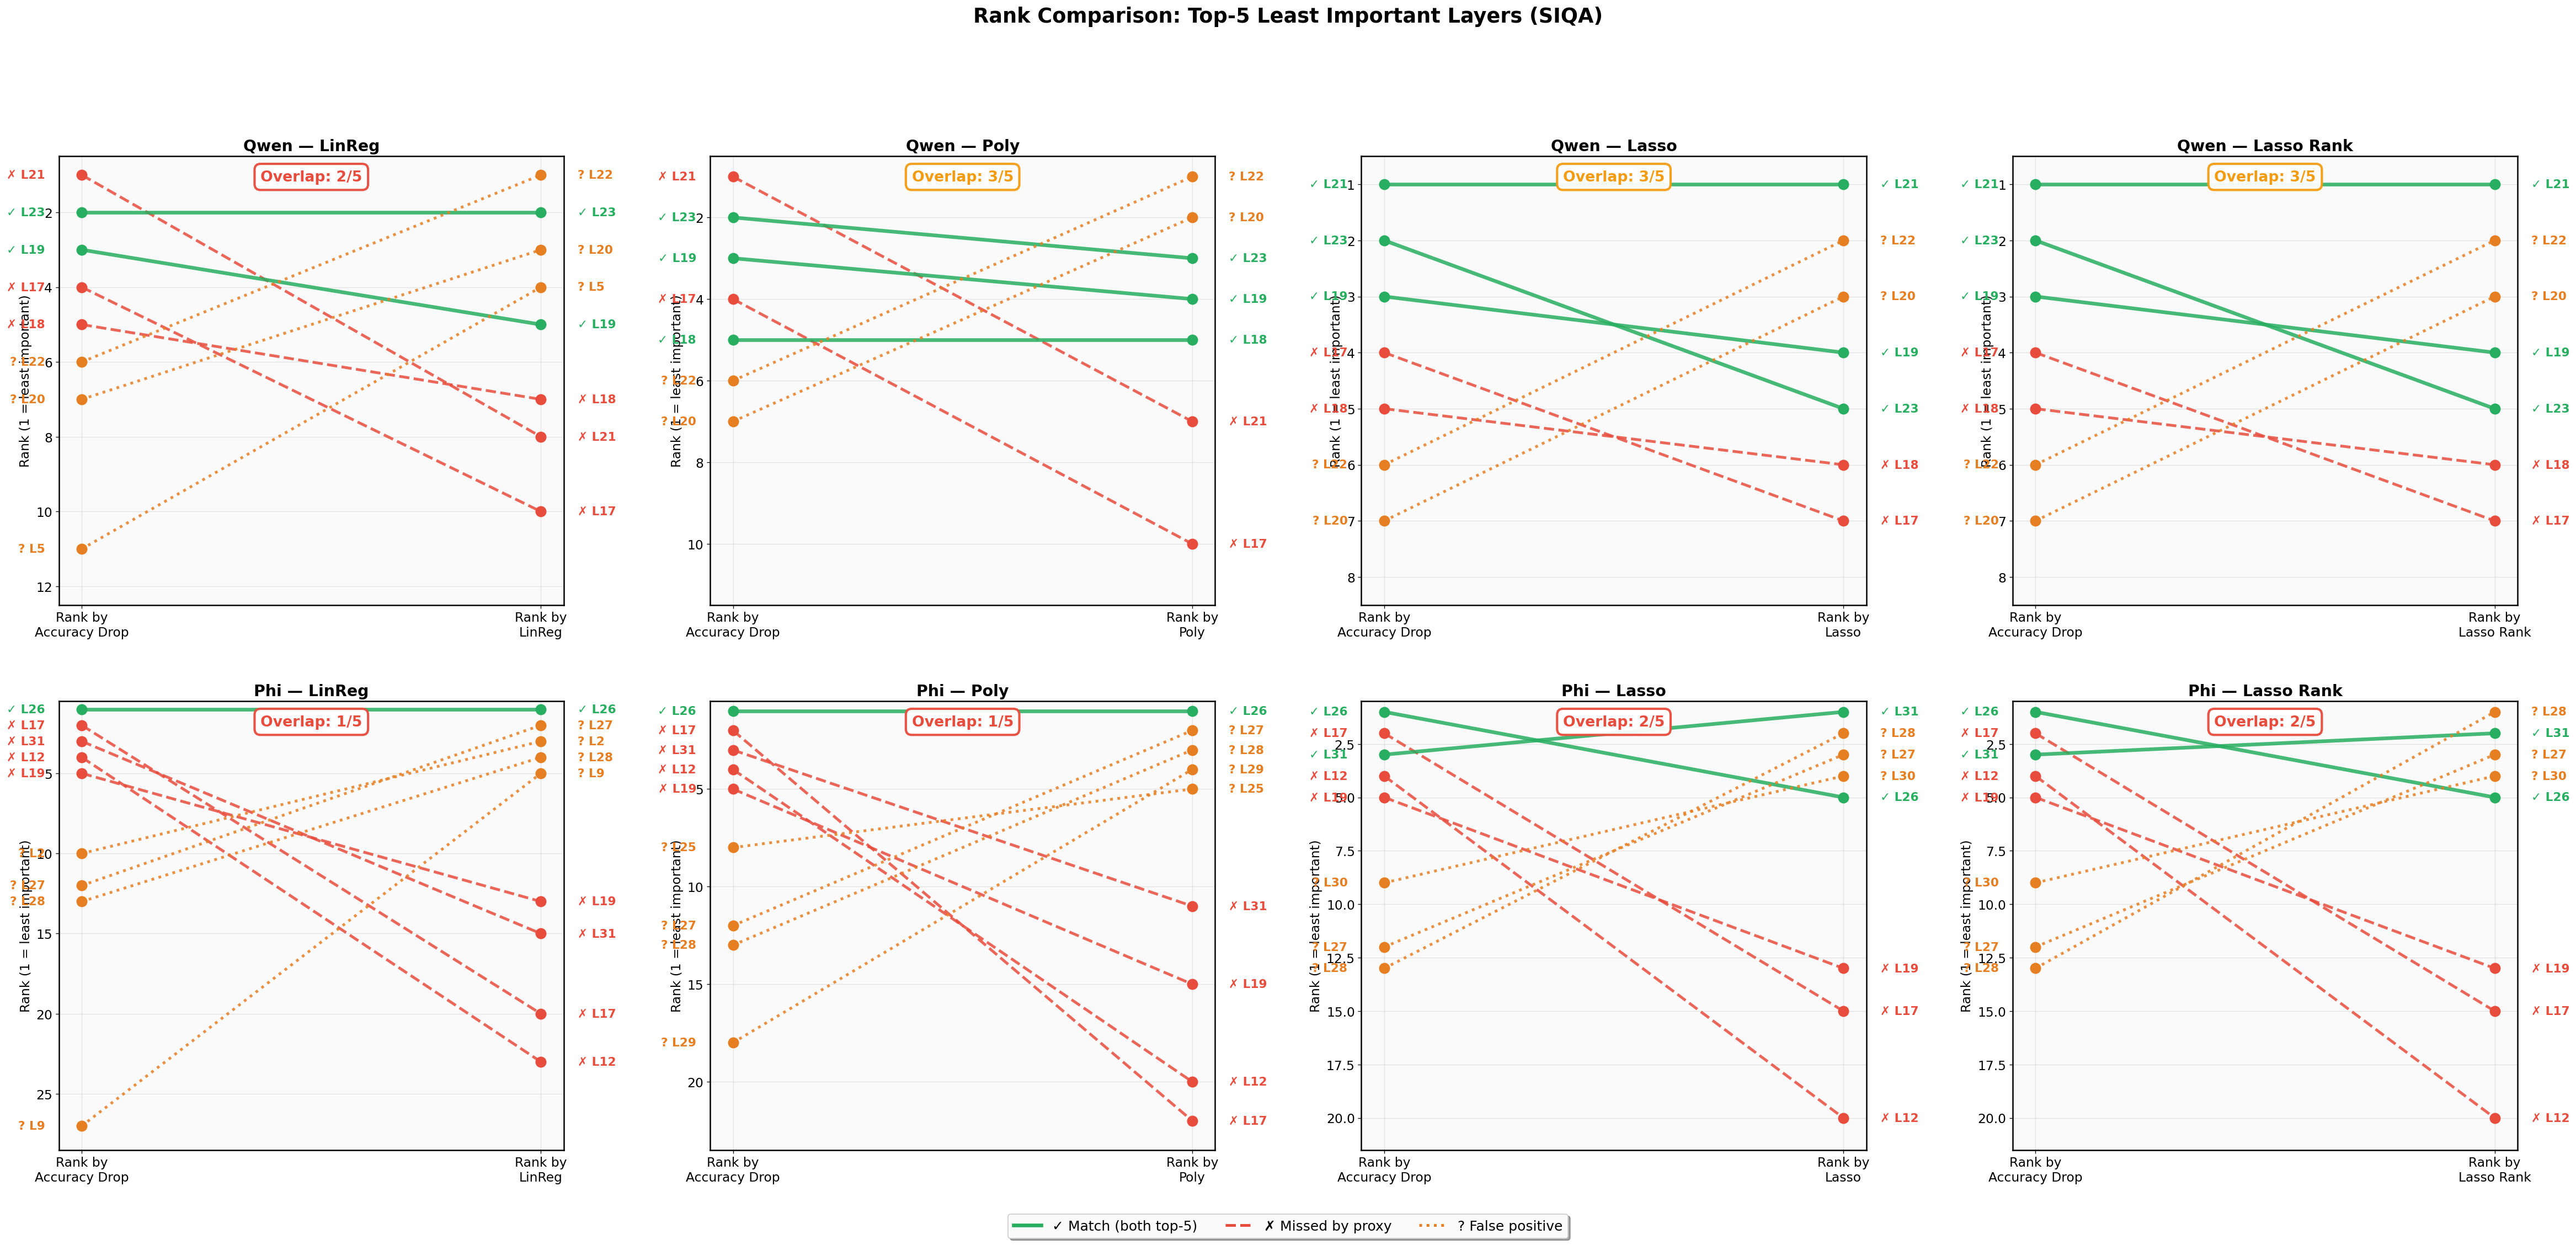

In [33]:
# Bump chart: TOP-5 LEAST important layers
# Green solid  = correctly identified (in both top-5)
# Red dashed   = missed by proxy (in top-5 drop only)
# Orange dotted = false positive (in top-5 proxy only)

proxy_short = {
    'Proxy_Metric': 'LinReg', 'Poly_Proxy': 'Poly',
    'Lasso_Proxy': 'Lasso', 'Lasso_Rank_Proxy': 'Lasso Rank',
}

fig, axes = plt.subplots(2, 4, figsize=(40, 18))

configs = [
    ('Qwen \u2014 LinReg',       'Qwen', 'Proxy_Metric'),
    ('Qwen \u2014 Poly',         'Qwen', 'Poly_Proxy'),
    ('Qwen \u2014 Lasso',        'Qwen', 'Lasso_Proxy'),
    ('Qwen \u2014 Lasso Rank',   'Qwen', 'Lasso_Rank_Proxy'),
    ('Phi \u2014 LinReg',        'Phi',  'Proxy_Metric'),
    ('Phi \u2014 Poly',          'Phi',  'Poly_Proxy'),
    ('Phi \u2014 Lasso',         'Phi',  'Lasso_Proxy'),
    ('Phi \u2014 Lasso Rank',    'Phi',  'Lasso_Rank_Proxy'),
]

TOP_K = 5

for flat_idx, (title, model_key, pcol) in enumerate(configs):
    row, col = flat_idx // 4, flat_idx % 4
    ax = axes[row, col]

    df_r = ranks_siqa[(model_key, pcol)]
    n = len(df_r)

    top_drop = set(df_r.nsmallest(TOP_K, 'Rank_Drop')['Layer'].values)
    top_proxy = set(df_r.nsmallest(TOP_K, 'Rank_Proxy')['Layer'].values)
    matched = top_drop & top_proxy
    missed = top_drop - top_proxy      # proxy didn't catch these
    false_pos = top_proxy - top_drop   # proxy wrongly flagged these
    show_layers = top_drop | top_proxy

    df_top = df_r[df_r['Layer'].isin(show_layers)]

    for _, r in df_top.iterrows():
        layer = r['Layer']
        if layer in matched:
            color, ls, lw, marker_ec = '#27ae60', '-', 4.0, '#27ae60'
            label_prefix = '\u2713 '
        elif layer in missed:
            color, ls, lw, marker_ec = '#e74c3c', '--', 3.0, '#e74c3c'
            label_prefix = '\u2717 '
        else:  # false_pos
            color, ls, lw, marker_ec = '#e67e22', ':', 3.0, '#e67e22'
            label_prefix = '? '

        ax.plot([0, 1], [r['Rank_Drop'], r['Rank_Proxy']], linestyle=ls,
                color=color, alpha=0.85, markersize=0, linewidth=lw)
        # Left marker
        ax.plot(0, r['Rank_Drop'], 'o', color=color, markersize=11, zorder=6)
        ax.text(-0.08, r['Rank_Drop'], f"{label_prefix}L{int(layer)}",
                ha='right', va='center', fontsize=13, fontweight='bold',
                color=color)
        # Right marker
        ax.plot(1, r['Rank_Proxy'], 'o', color=color, markersize=11, zorder=6)
        ax.text(1.08, r['Rank_Proxy'], f"{label_prefix}L{int(layer)}",
                ha='left', va='center', fontsize=13, fontweight='bold',
                color=color)

    all_ranks = list(df_top['Rank_Drop']) + list(df_top['Rank_Proxy'])
    margin = 1
    ymin = max(1, min(all_ranks) - margin)
    ymax = min(n, max(all_ranks) + margin)
    ax.set_ylim(ymax + 0.5, ymin - 0.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Rank by\nAccuracy Drop', f'Rank by\n{proxy_short[pcol]}'], fontsize=14)
    ax.set_ylabel('Rank (1 = least important)', fontsize=14)
    ax.set_title(title, fontsize=17, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Overlap badge
    overlap = len(matched)
    ov_color = '#27ae60' if overlap >= 4 else '#f39c12' if overlap >= 3 else '#e74c3c'
    ax.text(0.5, 0.97, f'Overlap: {overlap}/{TOP_K}',
            transform=ax.transAxes, ha='center', va='top', fontsize=16, fontweight='bold',
            color=ov_color,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=ov_color, linewidth=2.5, alpha=0.95))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#27ae60', linewidth=4, linestyle='-',  label='\u2713 Match (both top-5)'),
    Line2D([0], [0], color='#e74c3c', linewidth=3, linestyle='--', label='\u2717 Missed by proxy'),
    Line2D([0], [0], color='#e67e22', linewidth=3, linestyle=':',  label='? False positive'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=15,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Rank Comparison: Top-{TOP_K} Least Important Layers (SIQA)',
             fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)
plt.subplots_adjust(bottom=0.06)
plt.show()


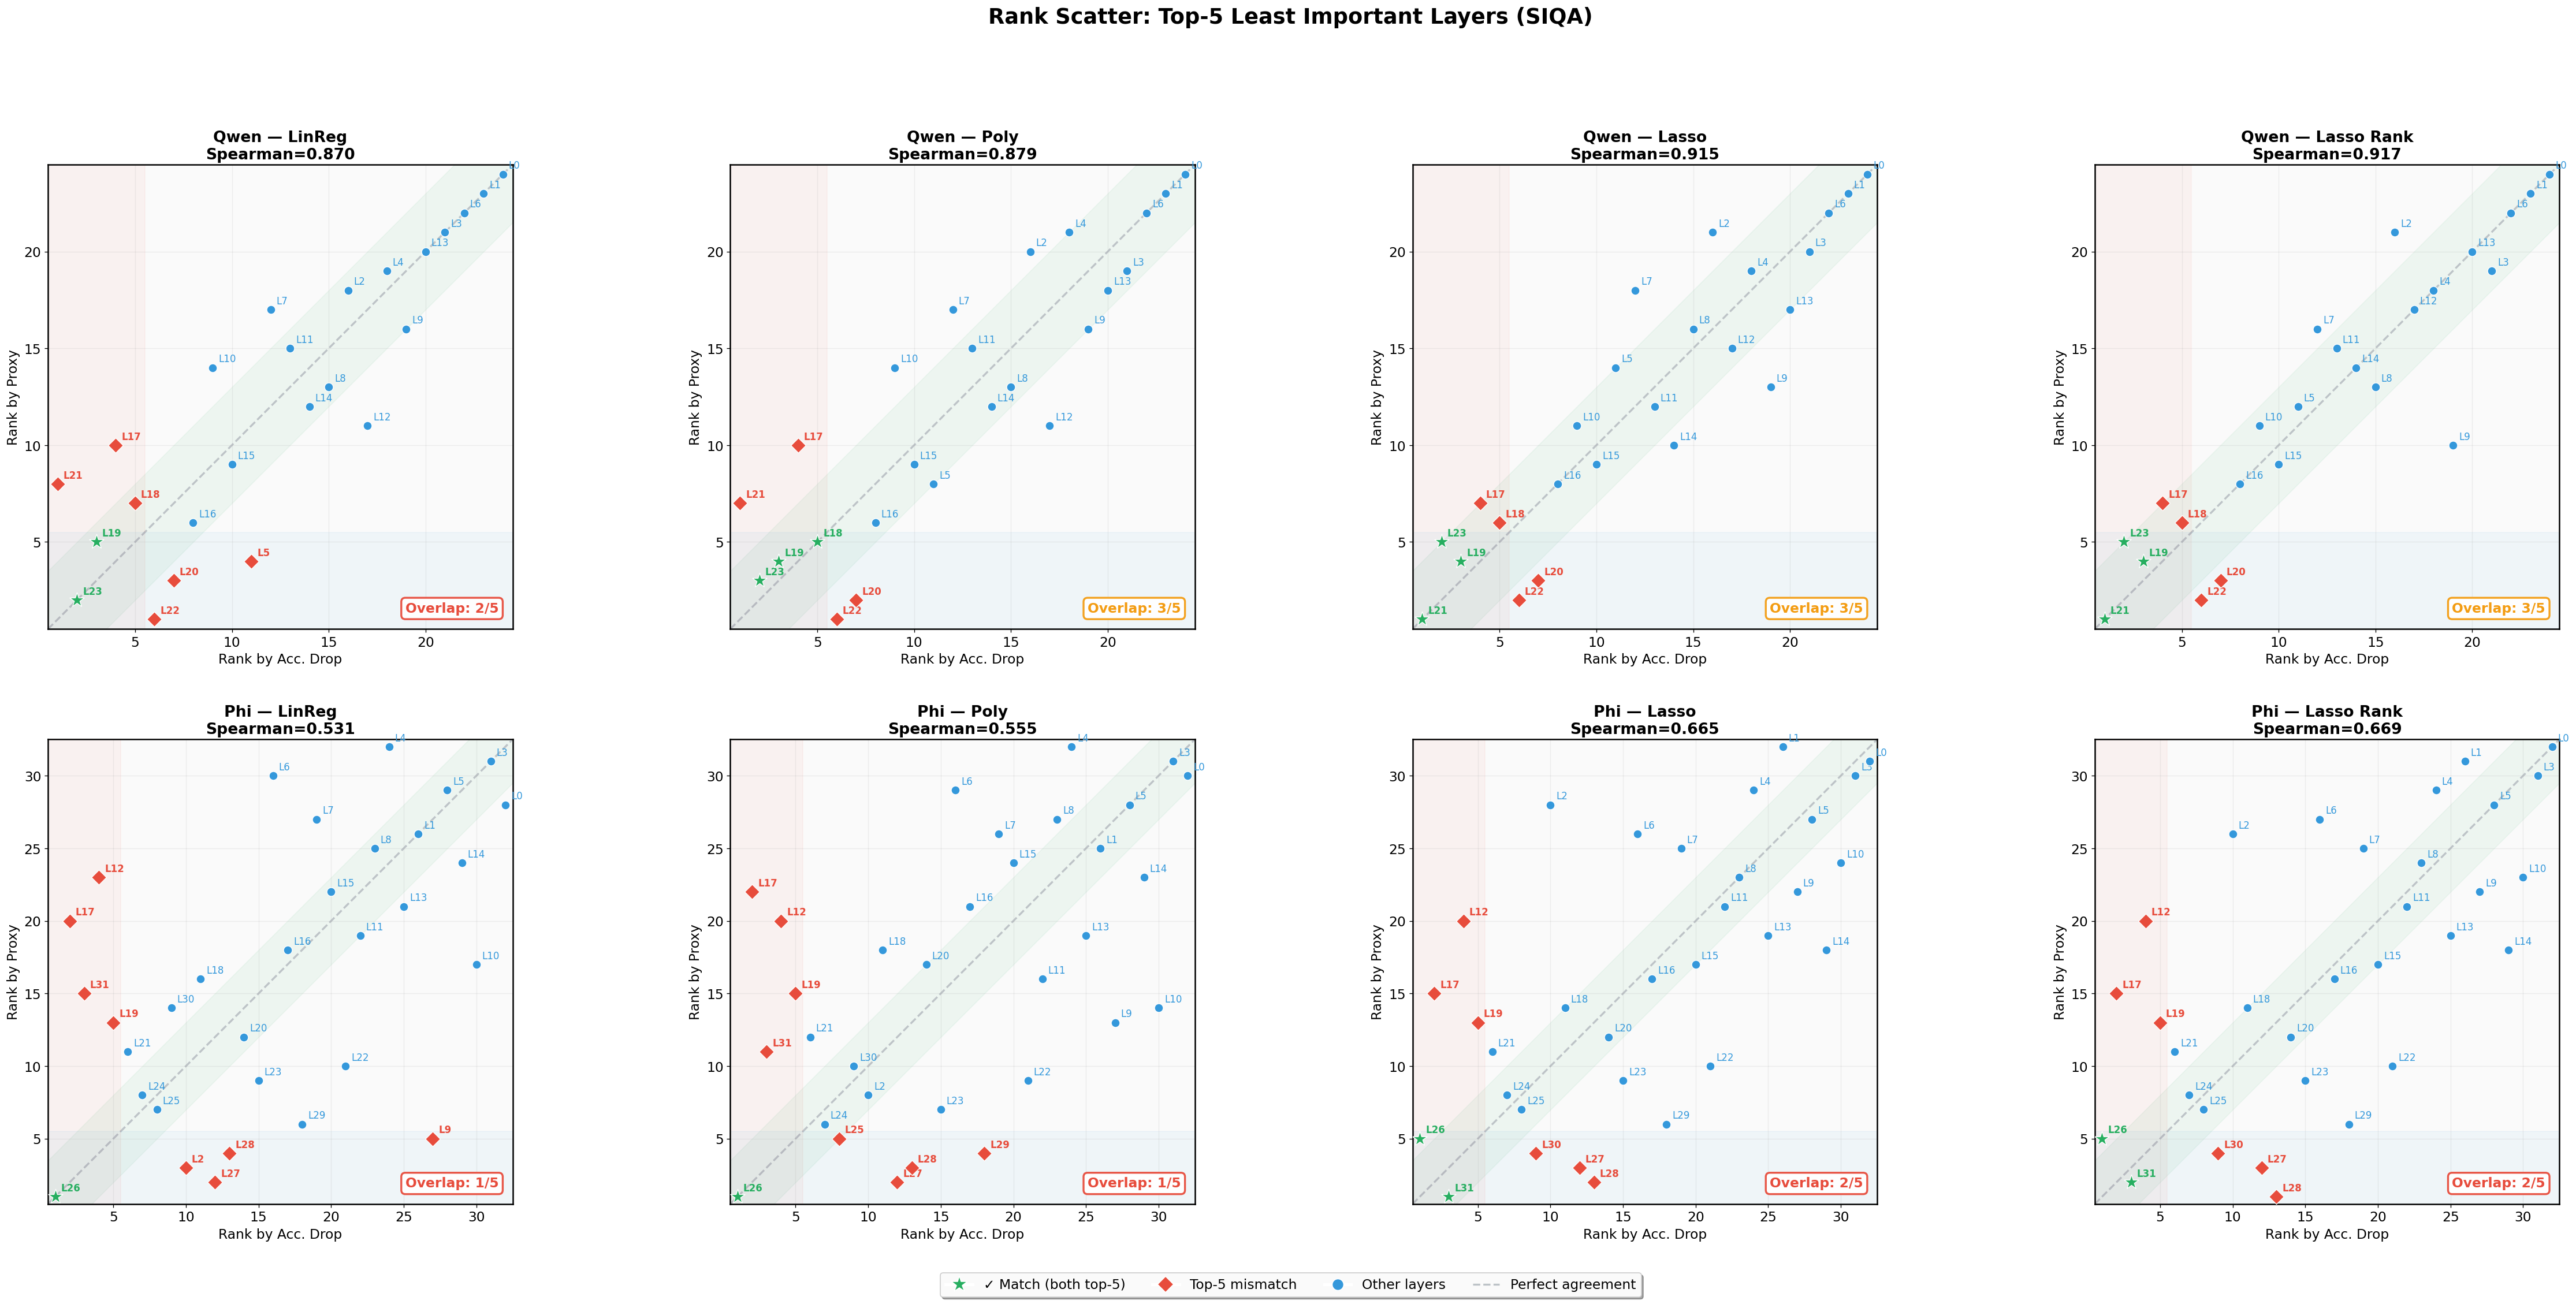

In [34]:
# Rank scatter plot: all proxies, SIQA

fig, axes = plt.subplots(2, 4, figsize=(40, 18))

configs = [
    ('Qwen \u2014 LinReg',       'Qwen', 'Proxy_Metric'),
    ('Qwen \u2014 Poly',         'Qwen', 'Poly_Proxy'),
    ('Qwen \u2014 Lasso',        'Qwen', 'Lasso_Proxy'),
    ('Qwen \u2014 Lasso Rank',   'Qwen', 'Lasso_Rank_Proxy'),
    ('Phi \u2014 LinReg',        'Phi',  'Proxy_Metric'),
    ('Phi \u2014 Poly',          'Phi',  'Poly_Proxy'),
    ('Phi \u2014 Lasso',         'Phi',  'Lasso_Proxy'),
    ('Phi \u2014 Lasso Rank',    'Phi',  'Lasso_Rank_Proxy'),
]

TOP_K = 5

for flat_idx, (title, model_key, pcol) in enumerate(configs):
    row, col = flat_idx // 4, flat_idx % 4
    ax = axes[row, col]

    df_r = ranks_siqa[(model_key, pcol)]
    n = len(df_r)

    top_drop = set(df_r.nsmallest(TOP_K, 'Rank_Drop')['Layer'].values)
    top_proxy = set(df_r.nsmallest(TOP_K, 'Rank_Proxy')['Layer'].values)
    matched = top_drop & top_proxy

    # Diagonal + tolerance band
    ax.plot([0.5, n+0.5], [0.5, n+0.5], '--', color='#bdc3c7', linewidth=2, zorder=1)
    ax.fill_between([0.5, n+0.5], [0.5-3, n+0.5-3], [0.5+3, n+0.5+3],
                    alpha=0.06, color='#27ae60', zorder=0)

    for _, r in df_r.iterrows():
        layer = int(r['Layer'])
        rd, rp = r['Rank_Drop'], r['Rank_Proxy']
        in_top_drop = layer in top_drop
        in_top_proxy = layer in top_proxy

        if layer in matched:
            color, marker, s = '#27ae60', '*', 250
        elif in_top_drop or in_top_proxy:
            color, marker, s = '#e74c3c', 'D', 120
        else:
            color, marker, s = '#3498db', 'o', 80

        ax.scatter(rd, rp, c=color, marker=marker, s=s, zorder=5,
                   edgecolors='white', linewidth=0.8)
        ax.annotate(f'L{layer}', (rd, rp), textcoords='offset points', xytext=(6, 6),
                    fontsize=10, fontweight='bold' if in_top_drop or in_top_proxy else 'normal',
                    color=color)

    # Top-K zones
    ax.axvspan(0.5, TOP_K + 0.5, alpha=0.05, color='#e74c3c')
    ax.axhspan(0.5, TOP_K + 0.5, alpha=0.05, color='#3498db')

    sr, _ = stats.spearmanr(df_r['Rank_Drop'], df_r['Rank_Proxy'])
    overlap = len(matched)
    ov_color = '#27ae60' if overlap >= 4 else '#f39c12' if overlap >= 3 else '#e74c3c'

    ax.set_xlabel('Rank by Acc. Drop', fontsize=14)
    ax.set_ylabel('Rank by Proxy', fontsize=14)
    ax.set_title(f'{title}\nSpearman={sr:.3f}', fontsize=16, fontweight='bold')
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(0.5, n + 0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

    ax.text(0.97, 0.03, f'Overlap: {overlap}/{TOP_K}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=14, fontweight='bold',
            color=ov_color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=ov_color, linewidth=2, alpha=0.95))

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#27ae60', markersize=18, label='\u2713 Match (both top-5)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#e74c3c', markersize=12, label='Top-5 mismatch'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=12, label='Other layers'),
    Line2D([0], [0], color='#bdc3c7', linewidth=2, linestyle='--', label='Perfect agreement'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=14,
           frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Rank Scatter: Top-{TOP_K} Least Important Layers (SIQA)',
             fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.subplots_adjust(bottom=0.06)
plt.show()


In [35]:
rows = []
for model, df_m, dataset in [
    ('Qwen', df_qwen, 'Commonsense'), ('Phi-Tiny', df_phi, 'Commonsense'),
    ('Qwen', df_qwen_siqa, 'SIQA'), ('Phi-Tiny', df_phi_siqa, 'SIQA'),
]:
    for proxy_col in proxy_names:
        pr, _ = stats.pearsonr(df_m['Abs_Drop'], df_m[proxy_col])
        sr, _ = stats.spearmanr(df_m['Abs_Drop'], df_m[proxy_col])
        rows.append({'Dataset': dataset, 'Model': model, 'Proxy': proxy_labels[proxy_col],
                     'Pearson': round(pr, 4), 'Spearman': round(sr, 4)})
pd.DataFrame(rows)

,Dataset,Model,Proxy,Pearson,Spearman
0,Commonsense,Qwen,Proxy (LinReg),-0.7080,-0.7621
1,Commonsense,Qwen,Poly Proxy,-0.7575,-0.7938
2,Commonsense,Qwen,Lasso Proxy,-0.7932,-0.8038
3,Commonsense,Qwen,Lasso Rank Proxy,-0.7732,-0.7986
4,Commonsense,Phi-Tiny,Proxy (LinReg),-0.4424,-0.7070
5,Commonsense,Phi-Tiny,Poly Proxy,-0.4679,-0.7085
6,Commonsense,Phi-Tiny,Lasso Proxy,-0.6512,-0.8617
7,Commonsense,Phi-Tiny,Lasso Rank Proxy,-0.6234,-0.8637
8,SIQA,Qwen,Proxy (LinReg),-0.7823,-0.8724
9,SIQA,Qwen,Poly Proxy,-0.8041,-0.8811
